# Krakow-Air-Quality-Forecast: PM10 Time Series Analysis

Kraków and the surrounding Małopolska region historically struggle with severe air pollution, particularly during the winter heating season. The primary concern is high concentrations of PM10 particulate matter, which pose significant health risks due to the region's specific valley topography and frequent temperature inversions. The objective of this notebook is to build a reliable and interpretable statistical model to forecast daily PM10 levels. We will begin our time series analysis with a baseline ARIMA model, subsequently upgrading to SARIMA to capture the strong seasonal patterns present in the pollution data. Finally, we will implement a SARIMAX model, incorporating exogenous weather variables such as temperature and wind speed to significantly improve our prediction accuracy. By the end of this analysis, we aim to demonstrate how meteorological factors influence smog dispersion and provide a robust forecasting tool.

## Libraries & Data Loading

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import requests
import holidays
import matplotlib.colors as mcolors
import matplotlib.cm as cm 
import matplotlib.colors as colors 
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from scipy.stats import boxcox
from datetime import datetime
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.special import inv_boxcox

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
# Load datasets

years = range(2019, 2025)

lista_df = [pd.read_excel(f'../data/{year}_PM10_24g.xlsx') for year in years]
pm10_all = pd.concat(lista_df, ignore_index=True)

In [3]:
pm10_all.head()

,Nr,1,2,3,4,5,6,7,8,9,...,170,171,172,173,174,175,176,177,178,179
0,Kod stacji,DsGlogWiStwo,DsJaworMOB,DsJelGorSoko,DsLegAlRzecz,DsNowRudJezi,DsOlawZolnAK,DsOlesBrzozo,DsOsieczow21,DsPolKasztan,...,WpWagrowLipo,ZpKolZolkiew,ZpKoszArKraj,ZpKoszSpasow,ZpMyslZaBram,ZpSzczAndr01,ZpSzczBudzWosMOB,ZpSzczec1Maj,ZpSzczecPrze,ZpSzczPils02
1,Wskaźnik,PM10,PM10,PM10,PM10,PM10,PM10,PM10,PM10,PM10,...,PM10,PM10,PM10,PM10,PM10,PM10,PM10,PM10,PM10,PM10
2,Czas uśredniania,24g,24g,24g,24g,24g,24g,24g,24g,24g,...,24g,24g,24g,24g,24g,24g,24g,24g,24g,24g
3,Jednostka,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,...,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3,ug/m3
4,Kod stanowiska,DsGlogWiStwo-PM10-24g,DsJaworMOB-PM10-24g,DsJelGorSoko-PM10-24g,DsLegAlRzecz-PM10-24g,DsNowRudJezi-PM10-24g,DsOlawZolnAK-PM10-24g,DsOlesBrzozo-PM10-24g,DsOsieczow21-PM10-24g,DsPolKasztan-PM10-24g,...,WpWagrowLipo-PM10-24g,ZpKolZolkiew-PM10-24g,ZpKoszArKraj-PM10-24g,ZpKoszSpasow-PM10-24g,ZpMyslZaBram-PM10-24g,ZpSzczAndr01-PM10-24g,ZpSzczBudzWosMOB-PM10-24g,ZpSzczec1Maj-PM10-24g,ZpSzczecPrze-PM10-24g,ZpSzczPils02-PM10-24g


All libraries and datasets were loaded and then merged to avoid having six separate datasets. Now we can proceed to the data preprocessing stage to clean the data and prepare it for the EDA section.

## Data Preprocessing

After merging the datasets, some rows contained metadata that were incorrectly interpreted as column names, so the format needs to be adjusted. Moreover, we can remove the rows labeled `Wskaźnik`, `Czas uśredniania`, `Jednostka` and `Kod stanowiska`, as they contain redundant information that is consistent across the dataset. The remaining relevant fields are `Kod stacji`, which will be used as columns to store the station identifier and the timestamps of the measurements.

In [4]:
air_data = pm10_all.copy()

air_data.columns = air_data.iloc[0]
air_data = air_data[1:].reset_index(drop=True)

air_data = air_data.iloc[4:].copy()
air_data = air_data.rename(columns={'Kod stacji': 'Date'})

In [5]:
air_data.head()

,Date,DsGlogWiStwo,DsJaworMOB,DsJelGorSoko,DsLegAlRzecz,DsNowRudJezi,DsOlawZolnAK,DsOlesBrzozo,DsOsieczow21,DsPolKasztan,...,WpWagrowLipo,ZpKolZolkiew,ZpKoszArKraj,ZpKoszSpasow,ZpMyslZaBram,ZpSzczAndr01,ZpSzczBudzWosMOB,ZpSzczec1Maj,ZpSzczecPrze,ZpSzczPils02
4,2019-01-01 00:00:00,13.71,13.15,22.24,15.86,NaN,12.52,21.93,14.26,13.65,...,23.83,14.33,13.75,14.55,8.55,22.18,NaN,11.55,9.88,18.25
5,2019-01-02 00:00:00,8.28,11.26,10.17,13.28,NaN,9.95,7.23,10.16,7.39,...,8.24,7.08,8.29,4.37,6.91,8.02,NaN,7.42,6.44,9.63
6,2019-01-03 00:00:00,8.06,13.87,12.92,16.72,NaN,NaN,9.41,10.52,6.46,...,11.36,6.35,9.4,7.09,10.91,12.7,NaN,9.51,13.16,13.64
7,2019-01-04 00:00:00,11.47,16.49,13.65,16.63,NaN,NaN,16.65,9.82,9.47,...,18.88,9.26,14.98,14.55,11.46,15.65,NaN,14.69,20.83,17.95
8,2019-01-05 00:00:00,6.67,8.69,8.02,12.19,NaN,10.27,8.1,7.93,4.19,...,13.05,6.35,7.23,9.46,13.09,14.03,NaN,8.13,8.67,12.89


As we prepare to forecast air quality in Kraków, we must first filter the dataset to include only the relevant monitoring stations. While there are numerous measurement stations across the city, including all of them could introduce unnecessary noise into our data. Instead, we have strategically selected four key stations located in different parts of Kraków. By averaging their measurements, we obtain a more stable and representative daily metric, which significantly improves the reliability of our forecasting models.

In [6]:
stations_list = ['MpKrakAlKras', 'MpKrakBujaka', 'MpKrakBulwar', 'MpKrakWadow']

cols_to_keep = ['Date'] + stations_list
krak_stations = air_data[cols_to_keep].copy()

krak_stations.head()

,Date,MpKrakAlKras,MpKrakBujaka,MpKrakBulwar,MpKrakWadow
4,2019-01-01 00:00:00,31.31,23.42,20.87,21.28
5,2019-01-02 00:00:00,12.99,10.56,8.23,7.3
6,2019-01-03 00:00:00,20.56,13.9,7.96,8.72
7,2019-01-04 00:00:00,54.41,27.16,20.11,19.53
8,2019-01-05 00:00:00,25.12,17.91,11.84,10.47


In [7]:
# Just to make sure that we have all rows from the original dataset

print(len(krak_stations) == len(air_data))

True


With the necessary data extracted and our key stations correctly structured, we can now proceed to the data cleaning phase.

In [8]:
krak_stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2217 entries, 4 to 2220
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          2217 non-null   object
 1   MpKrakAlKras  2194 non-null   object
 2   MpKrakBujaka  2168 non-null   object
 3   MpKrakBulwar  2160 non-null   object
 4   MpKrakWadow   2192 non-null   object
dtypes: object(5)
memory usage: 86.7+ KB


In [9]:
krak_stations.describe()

,Date,MpKrakAlKras,MpKrakBujaka,MpKrakBulwar,MpKrakWadow
count,2217,2194.0,2168.0,2160.00,2192.0
unique,2197,1195.0,1469.0,1418.00,1442.0
top,Kod stacji,14.7,15.3,25.36,14.9
freq,5,13.0,9.0,6.00,7.0


As we can observe, the `Date` column has an object data type, even though it contains only date values. Therefore, it should be converted to a datetime format. Also PM10 values are set as object type but we can transform them to float type.

In [10]:
krak_stations['Date'] = pd.to_datetime(krak_stations['Date'], errors='coerce')
krak_stations = krak_stations.dropna(subset=['Date'])
krak_stations = krak_stations.set_index('Date')

In [11]:
for col in stations_list:
    krak_stations[col] = krak_stations[col].astype(str).str.replace(',', '.').astype(float)

For the SARIMA model, it is important to have continuous data without any missing days. Therefore, we use the `asfreq` method to ensure a consistent time frequency.

In [12]:
krak_stations = krak_stations.asfreq('D')

When monitoring PM10 levels, outliers can occur due to sensor malfunctions or extraordinary localized events. We will apply the Interquartile Range (IQR) method to identify and handle these anomalies. However, we must be cautious: high PM10 readings during the winter are often legitimate reflections of increased pollution (the heating season). To avoid losing these critical data points, we will use a more conservative threshold (e.g., $3 \times IQR$) to target only extreme, unrealistic outliers.

In [13]:
krak_stations = krak_stations.interpolate(method='time')
krak_stations['PM10_Krakow_Avg'] = krak_stations[stations_list].mean(axis=1)

Q1 = krak_stations['PM10_Krakow_Avg'].quantile(0.25)
Q3 = krak_stations['PM10_Krakow_Avg'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 3.0 * IQR

We focus exclusively on the upper bound for outlier detection, as our primary concern is identifying uncharacteristic spikes in PM10 levels caused by sensor malfunctions. Extremely low values (near zero) represent exceptionally clean air and are physically plausible, whereas negative values are non-existent in this context. Furthermore, maintaining these low-pollution data points is essential for the models to learn the full variance and seasonal clean-air periods.

Our dataset contains several missing values (NaN) and formatting inconsistencies. To prepare the time series for forecasting, we apply time-based interpolation to fill these gaps. It is important to note that performing interpolation before the train-test split introduces a minimal, strictly local data leakage. However, this leakage is limited only to the immediate neighbors of the missing values and is necessary to maintain the temporal continuity required by models like SARIMA. This approach is significantly safer than global imputation (e.g., using the overall mean or median), which would cause a substantial data leakage by injecting future information into the training set.

In [14]:
krak_stations = krak_stations.interpolate(method='time')

We can perform resampling by creating a new version of the dataset aggregated at a monthly level. This will be useful for the EDA section, as it allows for clearer visualization of trends and dependencies in PM10 levels.

In [15]:
krak_monthly = krak_stations[['PM10_Krakow_Avg']].resample('MS').mean()

Meteorological conditions are pivotal exogenous variables that significantly influence air pollution dynamics. Factors such as wind speed and temperature are primary drivers of either the dispersion or the accumulation of particulate matter. For this analysis, we selected average temperature, total precipitation, and maximum wind speed as key environmental indicators. By merging these weather metrics with our core PM10 dataset into a single, unified dataframe, we provide our models with the necessary context to differentiate between emissions-based spikes and weather-driven anomalies. This data fusion is a critical step toward achieving higher predictive accuracy.

In [16]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 50.06,
	"longitude": 19.94,
	"start_date": "2019-01-01",
	"end_date": "2024-12-31",
	"daily": ["temperature_2m_mean", "precipitation_sum", "wind_speed_10m_max"],
	"timezone": "Europe/Berlin"
}

responses = requests.get(url, params=params)
data = responses.json()

weather_df = pd.DataFrame(data["daily"])
weather_df['time'] = pd.to_datetime(weather_df['time'])
weather_df.columns = ['date', 'temp_avg', 'rain_sum', 'wind_max']

print(weather_df.head())

        date  temp_avg  rain_sum  wind_max
0 2019-01-01       2.8       4.0      31.9
1 2019-01-02       0.8       6.4      33.5
2 2019-01-03      -2.8       0.7      27.0
3 2019-01-04      -3.3       1.7      19.4
4 2019-01-05       0.1       8.2      24.9


In [17]:
weather_df.describe()

,date,temp_avg,rain_sum,wind_max
count,2192,2192.000000,2192.000000,2192.000000
mean,2021-12-31 12:00:00,10.364918,2.484352,18.139462
min,2019-01-01 00:00:00,-15.300000,0.000000,4.000000
25%,2020-07-01 18:00:00,3.900000,0.000000,13.000000
50%,2021-12-31 12:00:00,10.300000,0.400000,17.100000
75%,2023-07-02 06:00:00,17.200000,2.700000,22.100000
max,2024-12-31 00:00:00,26.900000,66.700000,59.400000
std,NaN,7.957444,5.025624,7.052113


As we can see the weather dataset is pretty clear with no missing values, correct data types and no visible outliers, so we can move on to join datasets.

In [18]:
weather_df['date'] = pd.to_datetime(weather_df['date'])
weather_df = weather_df.set_index('date')

df_final = krak_stations.join(weather_df, how='left')

In [19]:
df_final.head()

,MpKrakAlKras,MpKrakBujaka,MpKrakBulwar,MpKrakWadow,PM10_Krakow_Avg,temp_avg,rain_sum,wind_max
Date,,,,,,,,
2019-01-01,31.31,23.42,20.87,21.28,24.2200,2.8,4.0,31.9
2019-01-02,12.99,10.56,8.23,7.30,9.7700,0.8,6.4,33.5
2019-01-03,20.56,13.90,7.96,8.72,12.7850,-2.8,0.7,27.0
2019-01-04,54.41,27.16,20.11,19.53,30.3025,-3.3,1.7,19.4
2019-01-05,25.12,17.91,11.84,10.47,16.3350,0.1,8.2,24.9


#### Data Preprocessing Summary

In this phase, we transformed the raw, fragmented sensor data into a clean, continuous time series. We addressed outliers and missing values by applying time-based interpolation and the `asfreq` method to ensure a gapless chronological sequence. After resampling the data to a daily frequency, we merged the PM10 dataset with key meteorological variables, including temperature, precipitation, and wind. This integration provides a unified foundation, enabling our models to leverage both historical trends and external environmental factors.

# Exploratory Data Analysis

### Section I - Data Overview

In this section, we conduct an Exploratory Data Analysis (EDA) to gain a deeper understanding of Kraków's air quality dynamics. We will examine the statistical distribution of PM10 concentrations, identify peak pollution periods, and visualize the 'heating season' effect. Through seasonal decomposition and monthly resampling, we will separate the long-term air quality trend from short-term fluctuations, ensuring our predictive models are built on a solid understanding of the historical data.

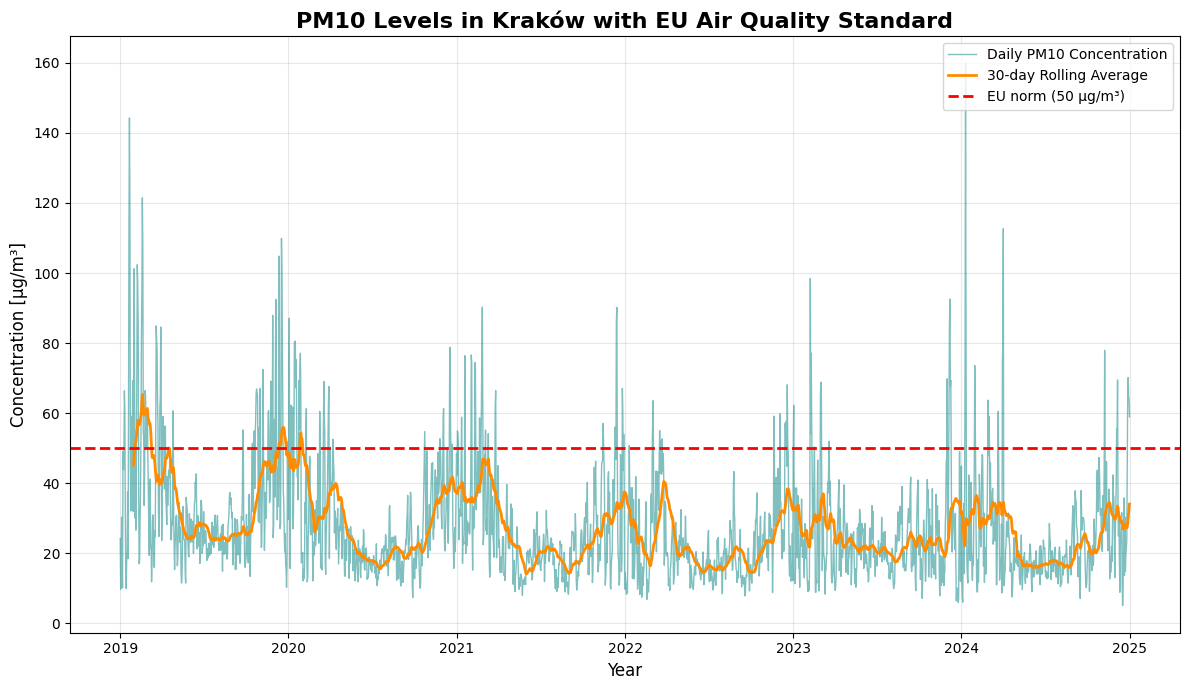

In [20]:
# Time serires with EU norm

plt.figure(figsize=(12, 7))

plt.plot(df_final.index, df_final['PM10_Krakow_Avg'], 
        color='teal', alpha=0.5, linewidth=1, label='Daily PM10 Concentration')

plt.plot(df_final['PM10_Krakow_Avg'].rolling(window=30).mean(),
        color='darkorange', linewidth=2, label='30-day Rolling Average')

plt.axhline(50, color='red', linestyle='--', linewidth=2, label='EU norm (50 µg/m³)')

plt.title('PM10 Levels in Kraków with EU Air Quality Standard', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Concentration [µg/m³]', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/eda_time_series.png', dpi=300)
plt.show()

The temporal distribution of $\text{PM}_{10}$ concentrations exhibits pronounced seasonal volatility, characterized by high-amplitude fluctuations during the boreal winter cycles (Q1 and Q4). During these domestic heating periods, the baseline frequently breaches the $40\ \mu g/m^3$ mark, with extreme transient events exceeding $140\ \mu g/m^3$. 

To mitigate the impact of high-frequency meteorological noise—such as wind gusts or precipitation events—a 30-day centered moving average was applied. This low-pass filter effectively isolates the underlying cyclical trend, revealing a clear contrast against the stabilized summer troughs of $20-30\ \mu g/m^3$ and providing a robust benchmark against the regulatory EU threshold of $50\ \mu g/m^3$.

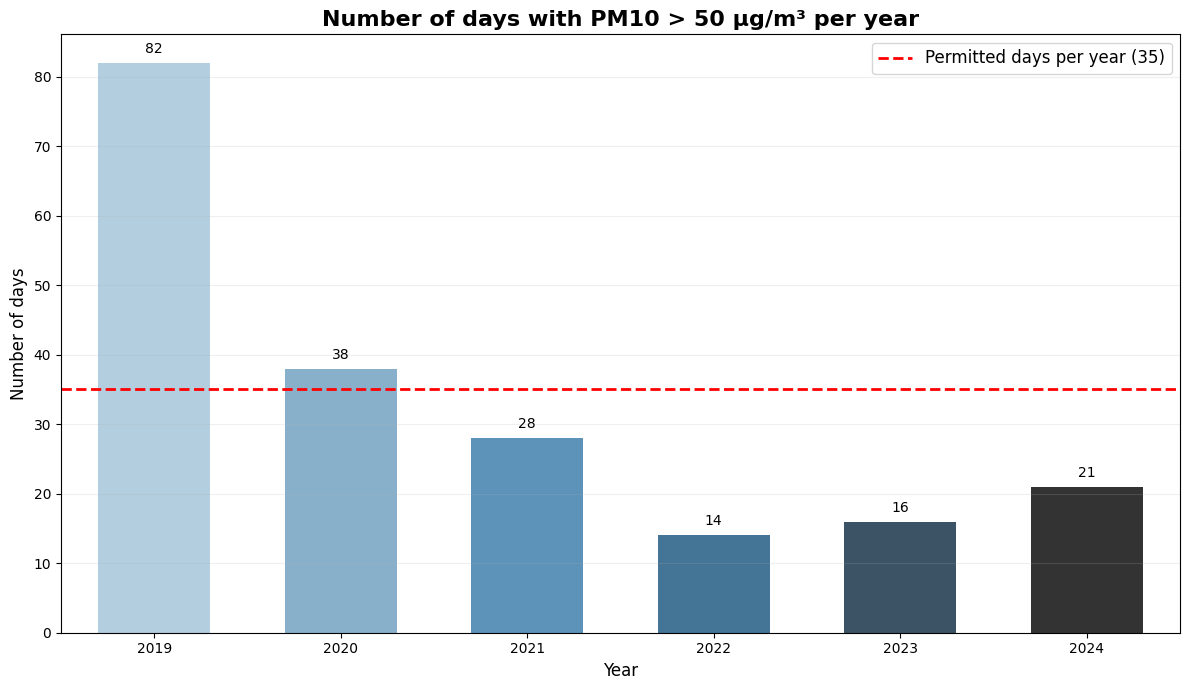

In [21]:
# EU norm exceedances grouped by year

krak_yearly = df_final['PM10_Krakow_Avg'].resample('YE').agg(['mean', 'max', 'count']).copy()

exceedances = df_final[df_final['PM10_Krakow_Avg'] > 50]['PM10_Krakow_Avg'].resample('YE').size()

krak_yearly['Days_above_50'] = exceedances.fillna(0).astype(int)

krak_yearly.index = krak_yearly.index.year
krak_yearly.columns = ['Avg_PM10', 'Max_PM10', 'Total_Days', 'Exceedance_Days']

plt.figure(figsize=(12, 7))

bars = sns.barplot(x=krak_yearly.index, y=krak_yearly['Exceedance_Days'], hue=krak_yearly.index, palette='Blues_d', width=0.6, legend=False)

for bar in bars.patches:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,             
        int(bar.get_height()),             
        ha='center',                      
        va='bottom',                       
        fontsize=10
    )

plt.axhline(y=35, color='red', linestyle='--', linewidth=2, label='Permitted days per year (35)')

plt.title('Number of days with PM10 > 50 µg/m³ per year', fontsize=16, fontweight='bold')
plt.ylabel('Number of days', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('../images/eda_exceedances_barplot.png', dpi=300)
plt.show()

This bar chart illustrates the annual number of days in Kraków when PM10 concentrations exceeded the health safety limit of $50\ \mu g/m^3$. The horizontal dashed red line marks the official permitted threshold of 35 days per year. 

In 2019, the city faced a critical air quality crisis, recording a staggering 82 days of excessive pollution. However, a significant downward trend is visible starting from 2020, indicating a steady improvement in the city's air quality. 

Since 2021, Kraków has successfully managed to stay below the legal limit, reaching its cleanest point in 2022 with only 14 exceedance days. Although there was a slight uptick to 21 days in 2024, the figures remain substantially lower than the initial levels recorded at the beginning of the study. The color gradient from light to dark blue visually emphasizes the passage of time and the shift toward more stable environmental conditions. 

Overall, this visualization provides strong evidence that the anti-smog policies implemented in recent years are yielding positive results.

### Section II — Seasonality and Temporal Patterns

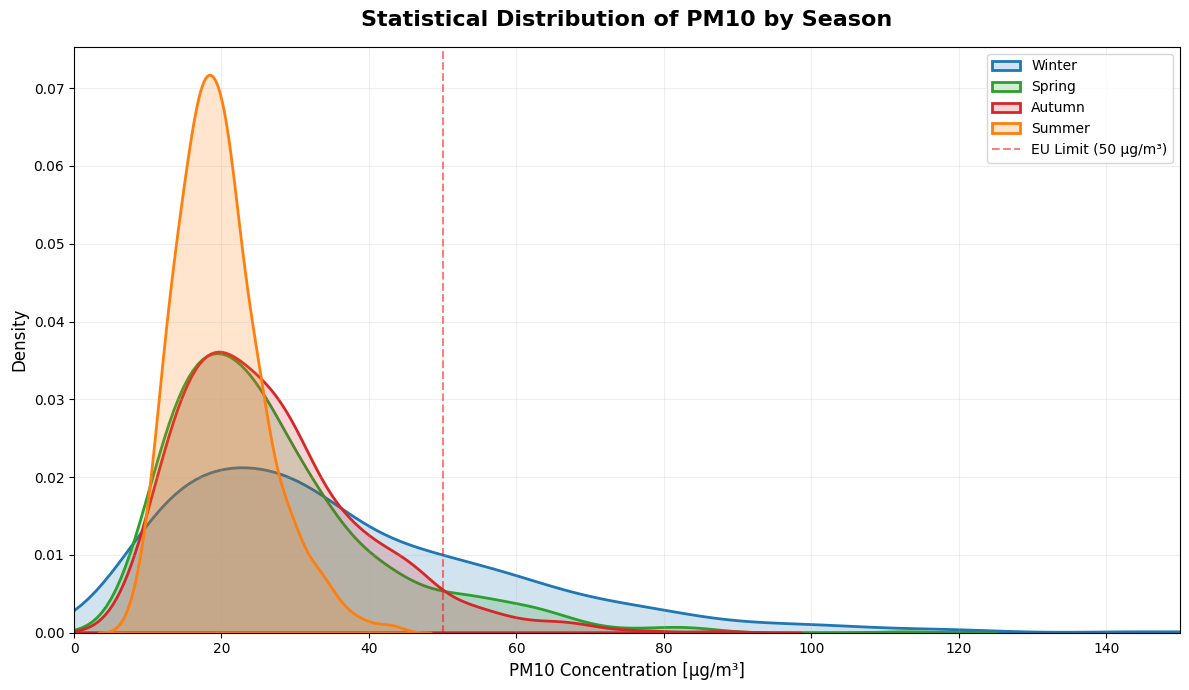

In [22]:
# Distribution of PM10 by Season

if 'month' not in df_final.columns:
    df_final['month'] = df_final.index.month

df_final["season"] = df_final["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
})

season_order = ["Winter", "Spring", "Autumn", "Summer"]
season_colors = ["#1f77b4", "#2ca02c", "#d62728", "#ff7f0e"]

plt.figure(figsize=(12, 7))

for season, color in zip(season_order, season_colors):
    sns.kdeplot(
        data=df_final[df_final['season'] == season]['PM10_Krakow_Avg'],
        label=season,
        color=color,
        fill=True,
        alpha=0.2,
        linewidth=2
    )

plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='EU Limit (50 µg/m³)')

plt.title("Statistical Distribution of PM10 by Season", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("PM10 Concentration [µg/m³]", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(0, 150)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("../images/eda_seasonal_distribution.png", dpi=300)
plt.show()

This KDE plot provides a sophisticated visualization of the probability density distribution for $\text{PM}_{10}$ concentrations across the four seasons in Kraków. By using a smooth density estimate instead of a standard histogram, the chart effectively highlights the distinct "shape" of air quality for each period. The Summer distribution, shown in orange, exhibits a sharp, leptokurtic peak centered around $20\ \mu g/m^3$, indicating highly stable and consistently clean air conditions. 

In stark contrast, the Winter distribution (blue) is significantly flatter and broader, reflecting much higher variance and unpredictability in pollution levels. A critical feature of the Winter curve is its pronounced "heavy tail," which extends far beyond the official EU safety threshold of $50\ \mu g/m^3$. The vertical dashed red line serves as a vital benchmark, clearly showing that Winter is the only season where a substantial portion of the probability mass falls within the hazardous zone. Spring and Autumn distributions occupy the middle ground, illustrating the gradual atmospheric transition between the clean summer baseline and winter peaks. The semi-transparent filling of the curves allows for an intuitive comparison of the overlapping regions between different seasonal cycles.

Visually, the chart is excellent, utilizing a minimalist grid and professional labeling to ensure the primary data story remains the focus. Overall, this visualization provides strong empirical evidence that seasonality is the dominant driver of air quality, justifying the use of a SARIMA-based forecasting approach.

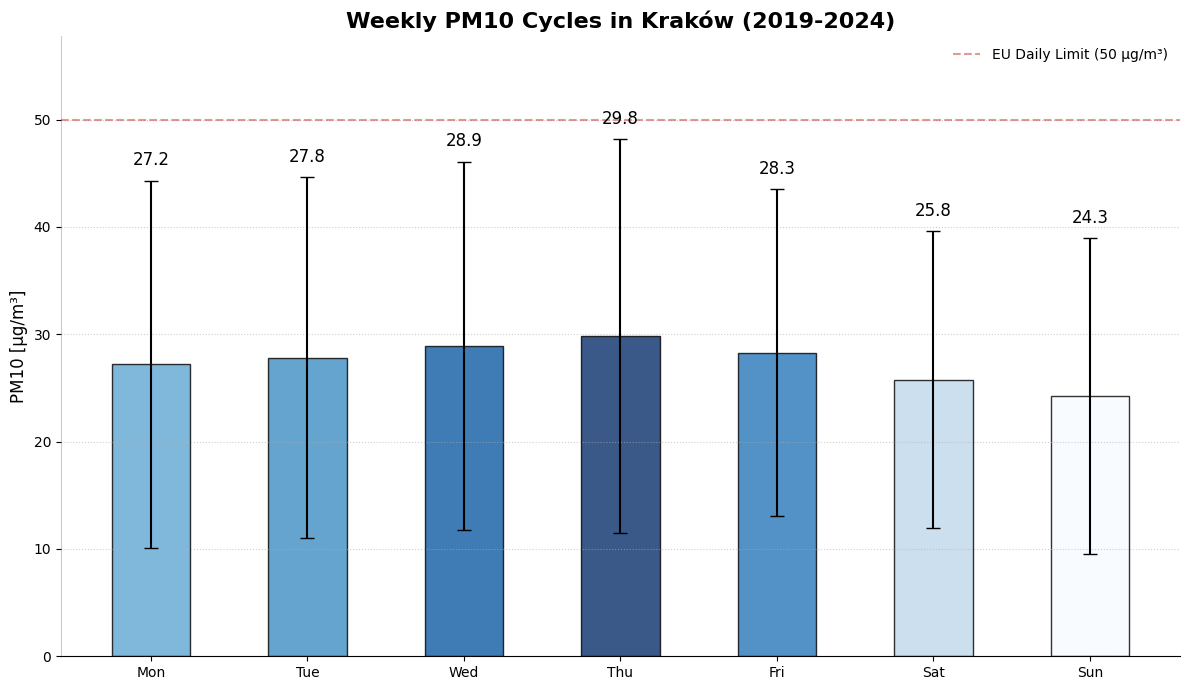

In [23]:
# Weekly analysis PM10 level

df_final['week'] = df_final.index.dayofweek
weekly = df_final.groupby('week')['PM10_Krakow_Avg'].agg(['mean', 'std'])
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

norm = mcolors.Normalize(vmin=weekly['mean'].min(), vmax=weekly['mean'].max())
cmap = plt.cm.Blues
colors_w = [cmap(norm(v)) for v in weekly['mean']]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    days, weekly['mean'], yerr=weekly['std'], capsize=5, color=colors_w, alpha=0.8,
    edgecolor='black', width=0.5
)

ax.bar_label(bars, padding=8, fmt='%.1f', fontsize=12)

ax.set_title("Weekly PM10 Cycles in Kraków (2019-2024)", fontsize=16, fontweight="bold")
ax.set_ylabel("PM10 [µg/m³]", fontsize=12)
ax.set_ylim(0, (weekly['mean'] + weekly['std']).max() * 1.2)

ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.2)

ax.axhline(50, color='#c0392b', linestyle='--', alpha=0.5, label='EU Daily Limit (50 µg/m³)')
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig('../images/eda_week_PM10_analysis.png', dpi=300)
plt.show()

This bar chart illustrates the average PM10 concentrations in Kraków across the days of the week for the period between 2019 and 2024. The visualization utilizes a sophisticated blue-intensity gradient, where darker hues correlate with higher pollution levels to enhance immediate visual interpretation. Across the entire week, the average values remain remarkably consistent, fluctuating within a narrow range between $24.3$ and $29.8\ \mu g/m^3$. Wednesday and Thursday are identified as the days with the highest averages, reaching $28.9\ \mu g/m^3$ and $29.8\ \mu g/m^3$, while Saturday marks the weekly minimum at $25.8\ \mu g/m^3$. 

Large error bars are included to represent the standard deviation, highlighting the significant daily volatility inherent in air quality data. The dashed red line at $50\ \mu g/m^3$ provides a vital regulatory context, showing that all weekly averages stay well below the official EU daily limit. The lack of a pronounced drop during the weekend suggests that stationary heating sources may have a more dominant impact on air quality than cyclical traffic patterns. 

Minimalist design elements, such as the removal of top and right spines, ensure that the focus remains entirely on the data trends. By aggregating six years of records, the chart offers a robust statistical profile of the city's weekly atmospheric baseline. This consistency across the week indicates that seasonal and meteorological factors will likely serve as stronger predictors for the upcoming modeling phase.

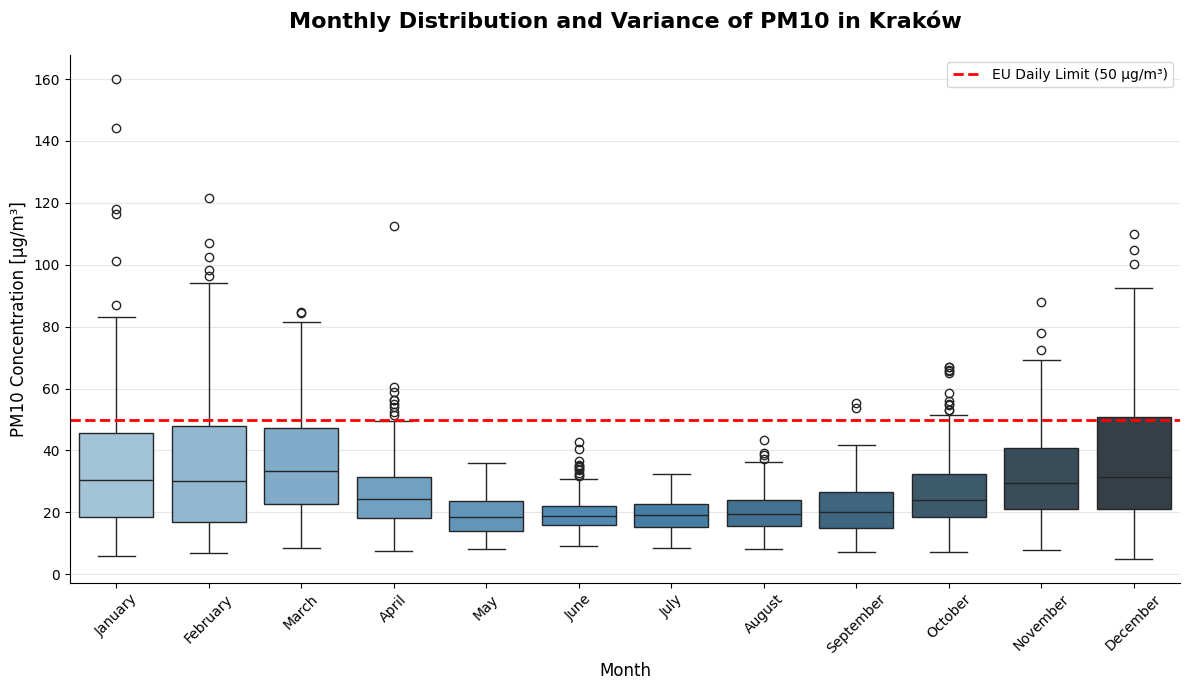

In [24]:
# Boxplots by months

df_final['month_name'] = df_final.index.month_name()
month_order = list(calendar.month_name)[1:]

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_final,
    x='month_name',
    y='PM10_Krakow_Avg',
    hue='month_name',
    order=month_order,
    palette='Blues_d'
)

plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='EU Daily Limit (50 µg/m³)')

plt.title('Monthly Distribution and Variance of PM10 in Kraków', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('PM10 Concentration [µg/m³]', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)

plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('../images/eda_monthly_boxplots.png', dpi=300)
plt.show()

This boxplot visualization provides a detailed look at the statistical distribution and monthly variance of PM10 concentrations in Kraków. The horizontal red dashed line serves as a critical benchmark, representing the official EU daily limit of $50\ \mu g/m^3$. A dominant seasonal trend is immediately apparent, with the highest medians and widest spreads occurring during the winter heating season. In months like January and February, the interquartile ranges (IQR) are significantly larger, indicating high day-to-day volatility in air quality. These winter periods are also marked by numerous extreme outliers, some exceeding $160\ \mu g/m^3$ during acute pollution episodes. 

Conversely, the summer months—from May to August—exhibit highly compressed boxes and low medians, reflecting a stable and non-hazardous baseline. During this warm period, the majority of the data points, including the whiskers, remain comfortably below the legal safety threshold. The transitional months of April and October clearly illustrate the city's shift in and out of the high-emission residential heating cycle. This visualization effectively highlights that Kraków's air quality crisis is not just a matter of higher averages, but of extreme, unpredictable peaks during the cold months. 

Ultimately, the chart confirms the necessity of seasonal-aware forecasting models to capture these divergent atmospheric behaviors.

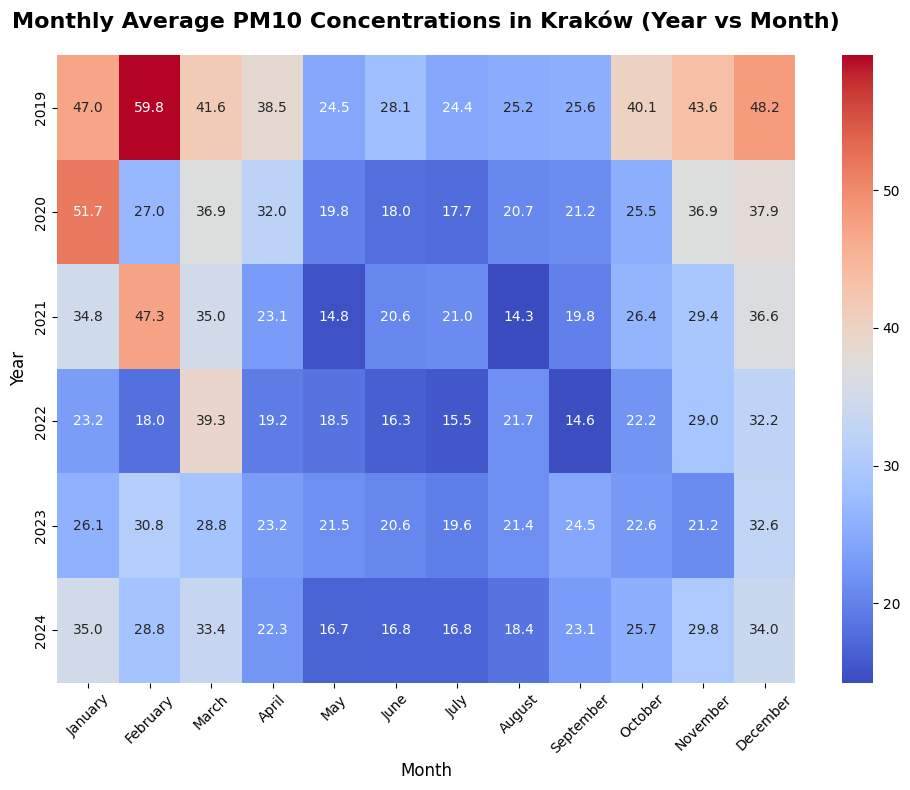

In [25]:
# Heatmap - month × year

df_final['year'] = df_final.index.year

pivot_data = df_final.pivot_table(
    values='PM10_Krakow_Avg',
    index=df_final['year'],
    columns=df_final['month'],
    aggfunc='mean'
)

pivot_data.columns = [calendar.month_name[m] for m in pivot_data.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_data,
    annot=True,
    fmt='.1f',
    cmap='coolwarm'
)

plt.title('Monthly Average PM10 Concentrations in Kraków (Year vs Month)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../images/eda_heatmap_month_year.png', dpi=300)
plt.show()

The matrix provides a high-resolution longitudinal synthesis of Kraków’s $\text{PM}_{10}$ evolution, revealing a distinct secular trend toward improved air quality. The significant chromatic shift—transitioning from the saturated red-spectrum peaks of 2019 to the more temperate blue-spectrum dominance of 2022–2024—indicates a structural downward shift in monthly arithmetic means. Furthermore, the persistent low-variance troughs observed during the central summer band (May–August) underscore a high correlation between pollution intensity and seasonal atmospheric boundary layer conditions. 

This visualization confirms that while high-volatility episodes persist, the overall pollution baseline has been successfully mitigated, shifting the city's profile from one of chronic year-round risk to isolated, seasonal peaks.

### Section III - Exogenous Variables Analysis

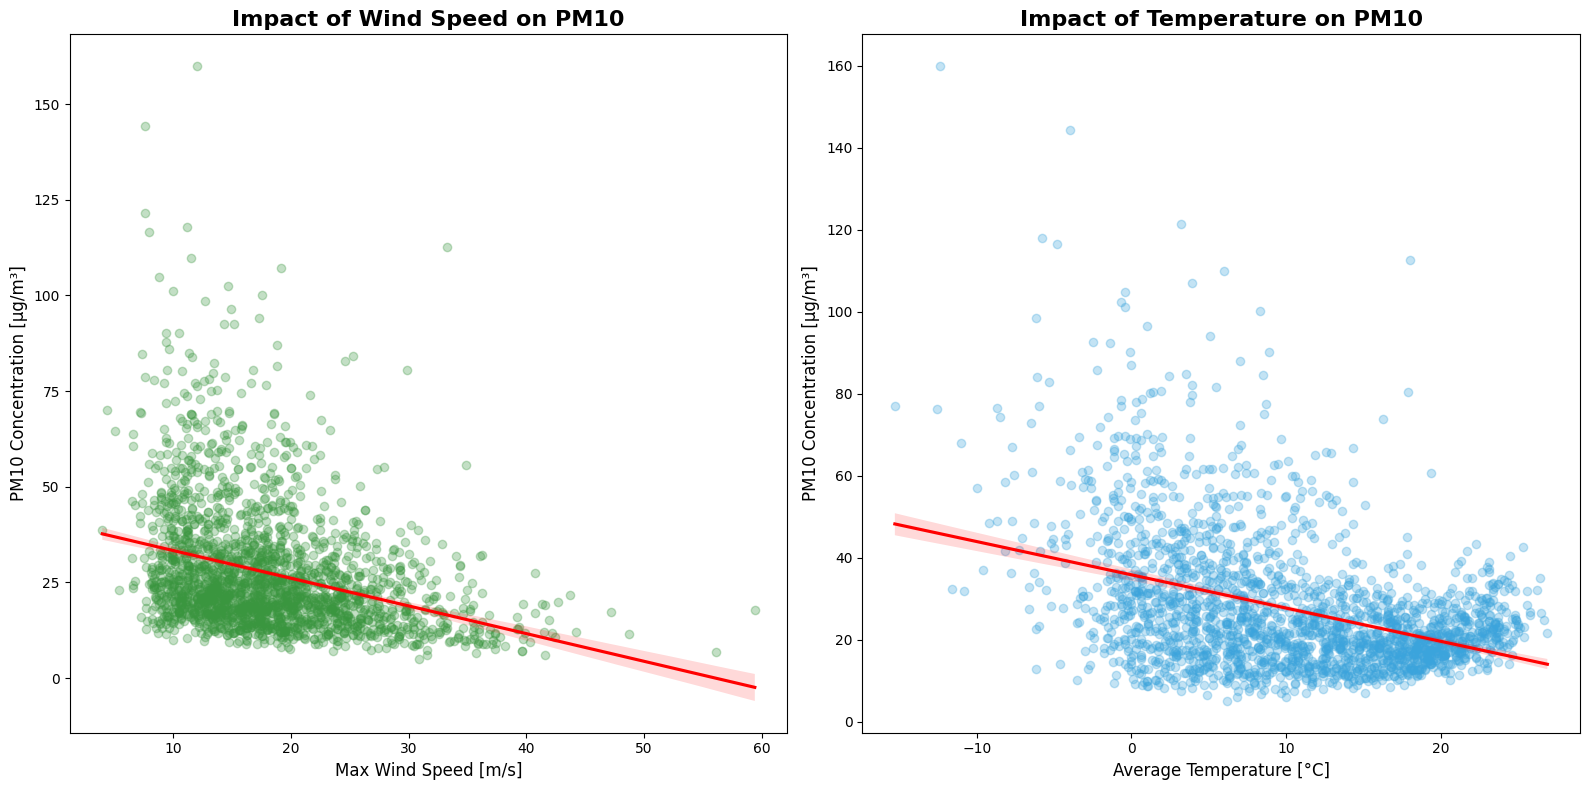

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.regplot(data=df_final, x='wind_max', y='PM10_Krakow_Avg', 
            scatter_kws={'alpha':0.3, 'color':"#3A963F"}, line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title('Impact of Wind Speed on PM10', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Max Wind Speed [m/s]', fontsize=12)
axes[0].set_ylabel('PM10 Concentration [µg/m³]', fontsize=12)

sns.regplot(data=df_final, x='temp_avg', y='PM10_Krakow_Avg', 
            scatter_kws={'alpha':0.3, 'color':"#3ba4dc"}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Impact of Temperature on PM10', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Average Temperature [°C]', fontsize=12)
axes[1].set_ylabel('PM10 Concentration [µg/m³]', fontsize=12)

plt.tight_layout()
plt.savefig('../images/weather_scatter_plots.png', dpi=300)
plt.show()

The dual scatter plots show how the main weather predictors relate to PM10 across the dataset. In the first panel, there is a negative trend between `wind_max` and PM10, indicating that stronger wind is generally associated with lower particulate levels, which is expected due to dispersion effects. The second panel shows a negative relationship between temperature and PM10, revealing the heating-season effect where colder days tend to have worse air quality. Both plots include regression lines that make the tendency obvious and support using these features in a SARIMAX model. 

This visualization confirms that meteorological variables are meaningful exogenous covariates but not perfect predictors, so model residuals will still capture other effects. Because the points are somewhat scattered, the model should include lagged or rolling features in addition to raw weather. 

The figure is particularly useful for communicating to stakeholders that weather conditions directly influence pollution dynamics. It also justifies including these features in the next model-building steps. In short: the scatter plot by itself is evidence that weather is informative and helpful in reducing forecasting error.

C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\3347370055.py:1: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df_year = df_final.last('1Y')
C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\3347370055.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_year = df_final.last('1Y')


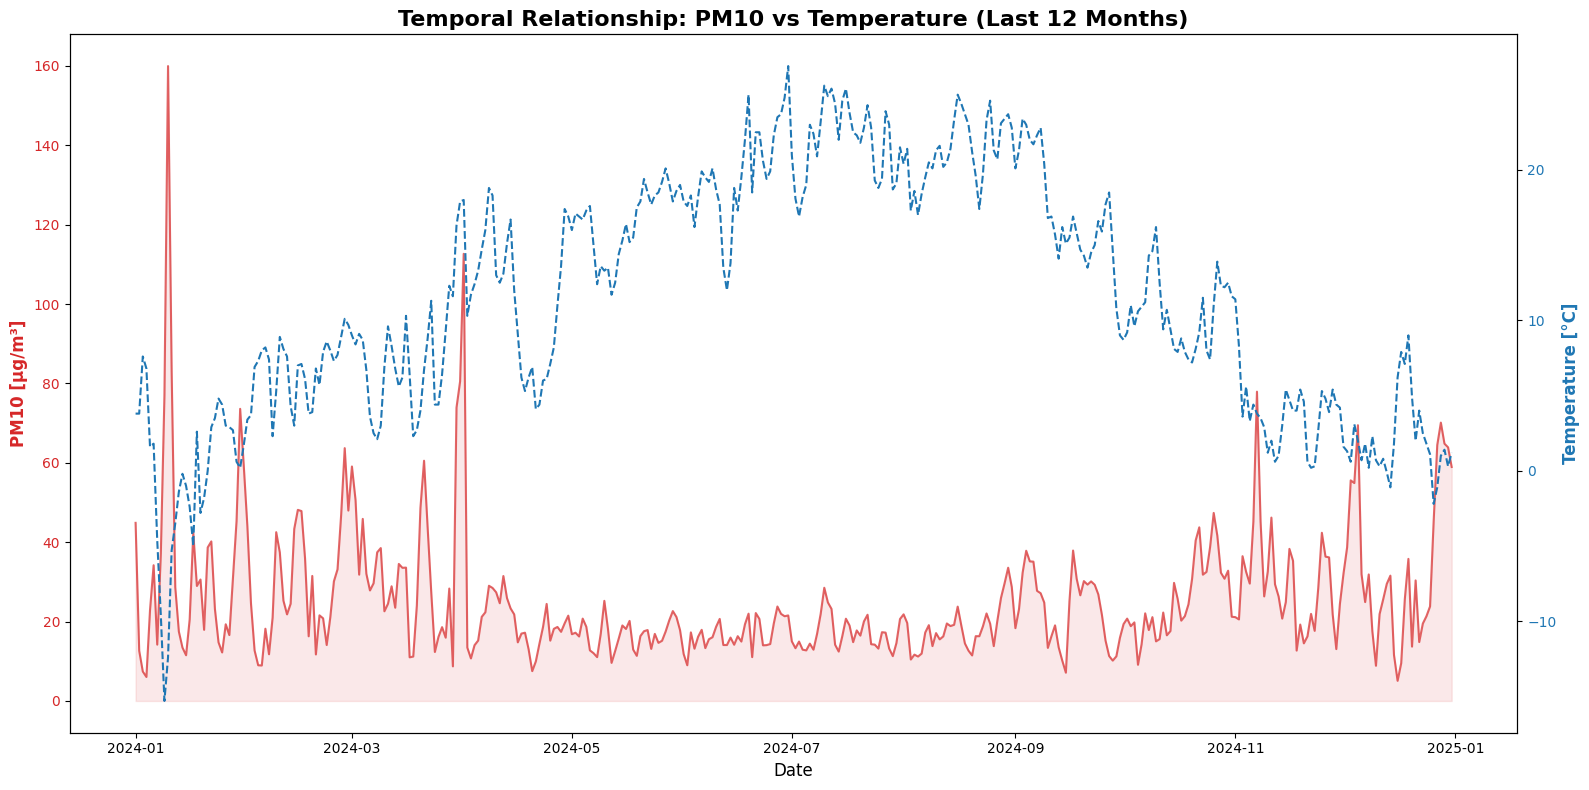

In [27]:
df_year = df_final.last('1Y')

fig, ax1 = plt.subplots(figsize=(16, 8))

color1 = 'tab:red'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('PM10 [µg/m³]', color=color1, fontsize=12, fontweight='bold')
ax1.plot(df_year.index, df_year['PM10_Krakow_Avg'], color=color1, alpha=0.7, label='PM10')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.fill_between(df_year.index, df_year['PM10_Krakow_Avg'], color=color1, alpha=0.1)

ax2 = ax1.twinx() 
color2 = 'tab:blue'
ax2.set_ylabel('Temperature [°C]', color=color2, fontsize=12, fontweight='bold')
ax2.plot(df_year.index, df_year['temp_avg'], color=color2, linestyle='--', label='Temperature')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Temporal Relationship: PM10 vs Temperature (Last 12 Months)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/weather_dual_axis_timeseries.png', dpi=300)
plt.show()

The dual-axis timeseries illustrates the last 12 months of PM10 and temperature together. It highlights the strong inverse seasonal relationship: peaks in PM10 often coincide with temperature troughs in winter, while cleaner air appears during warmer periods. The separate y-axes allow both variables to share one x-axis timeline without distorting scale and make their co-movement easy to inspect. 

This plot demonstrates that weather-based predictors are not only statistically correlated but also temporally aligned with pollution episodes. Gradual transitions and pronounced winter spikes are clearly visible, underscoring that short-term PM10 peaks are usually meteorologically driven. For forecasting, this means using `temp_avg` as a leading feature is justified, especially when combined with lagged pollution values. 

The chart also serves as a communication tool for non-technical audiences to understand the seasonality risk. Finally, it reinforces the preseason action strategy: temperature warnings are useful signals for anticipating high PM10 events.

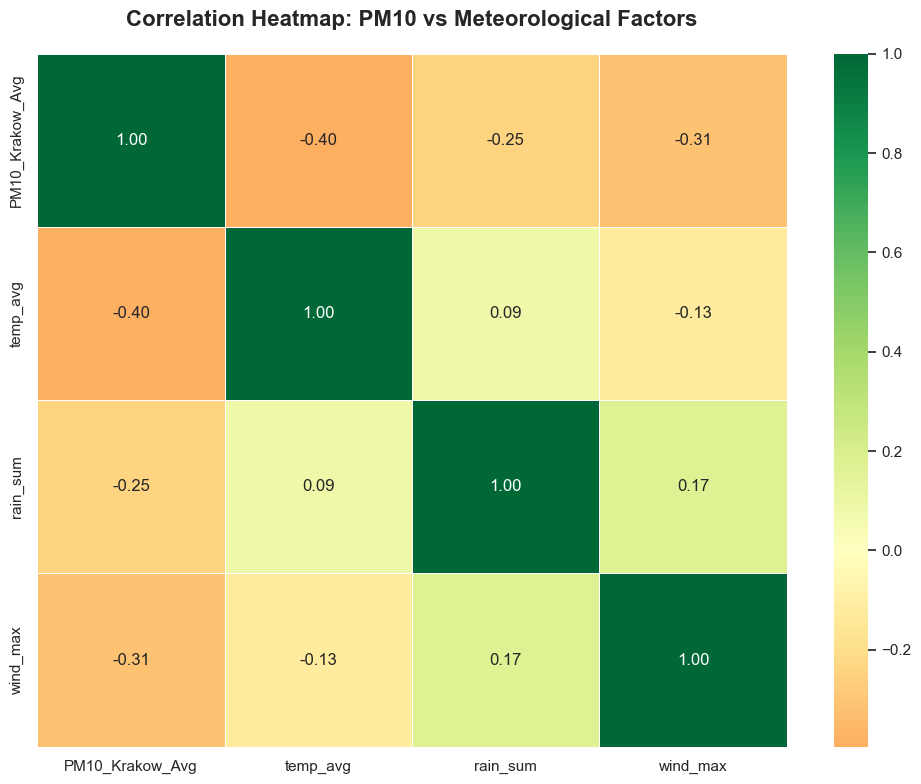

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ustawienie stylu
sns.set_theme(style="whitegrid")

# Wybieramy kolumny do korelacji
cols_to_corr = ['PM10_Krakow_Avg', 'temp_avg', 'rain_sum', 'wind_max']
corr_matrix = df_final[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", center=0, linewidths=0.5)
plt.title('Correlation Heatmap: PM10 vs Meteorological Factors', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../images/weather_correlation_heatmap.png', dpi=300)
plt.show()

The correlation heatmap provides empirical evidence of the relationship between PM10 concentrations and meteorological factors. All selected exogenous variables show a statistically significant negative correlation with the target:

- Temperature (-0.40): Shows the strongest impact, validating the "heating season" hypothesis where lower temperatures lead to increased domestic emissions.

- Wind Speed (-0.31): Confirms the atmospheric dispersion effect, where higher wind speeds facilitate the removal of particulate matter from the city basin.

- Precipitation (-0.25): Indicates a moderate "wash-out" effect during rainy days.

Importantly, the low inter-correlation between weather features suggests that each variable provides unique information, minimizing the risk of multicollinearity and enhancing the stability of the upcoming forecasting models.

### Section IV — Key Insights: Extreme Events

C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\1133938632.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Reds')


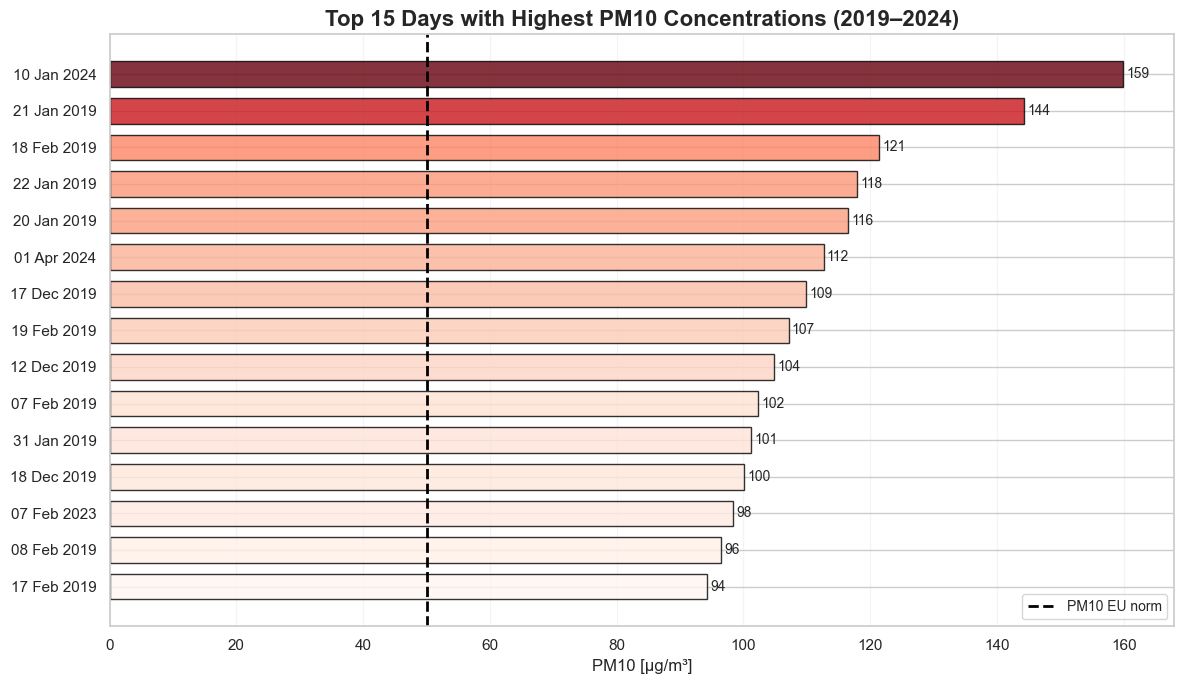

In [29]:
# Top 15 most polluted days

top_days = df_final['PM10_Krakow_Avg'].nlargest(15).reset_index()
top_days['label'] = top_days['Date'].dt.strftime("%d %b %Y")

norm = colors.Normalize(vmin=top_days['PM10_Krakow_Avg'].min(), vmax=top_days['PM10_Krakow_Avg'].max())
cmap = cm.get_cmap('Reds')
colors_gradient = [cmap(norm(value)) for value in top_days['PM10_Krakow_Avg']]

fig, ax = plt.subplots(figsize=(12 ,7))

bars = ax.barh(
    top_days['label'][::-1], top_days['PM10_Krakow_Avg'][::-1], color=colors_gradient[::-1], 
    alpha=0.8, edgecolor='black', height=0.7
)

for bar in bars:
    plt.text(bar.get_width() + 0.5,               
             bar.get_y() + bar.get_height()/2, 
             int(bar.get_width()),             
             va='center', fontsize=10)

ax.axvline(50, color='black', linestyle='--', linewidth=2, label='PM10 EU norm')

ax.set_title("Top 15 Days with Highest PM10 Concentrations (2019–2024)", fontsize=16, fontweight="bold")
ax.set_xlabel("PM10 [µg/m³]", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, axis="x")

plt.tight_layout()
plt.savefig("../images/top15_peak_pollution_events.png", dpi=300)
plt.show()

This horizontal bar chart illustrates the top 15 days with the highest PM10 concentrations recorded between 2019 and 2024. The vertical axis lists the specific dates, while the horizontal axis measures the pollution levels in $\mu g/m^3$. The highest peak was recorded on January 10, 2024, reaching a staggering 159 $\mu g/m^3$. 

A vertical dashed line marks the PM10 EU norm at 50 $\mu g/m^3$ for reference. Notably, every day shown in this ranking significantly exceeds this health standard, with many values more than tripling the limit. The chart uses a color gradient, where darker red shades emphasize the most severe air quality violations. Most of the recorded peaks occurred during the winter months, specifically in January, February, and December. Although 2019 appears most frequently in the top 15, the overall record belongs to early 2024. Even the 15th highest value on the list (94 $\mu g/m^3$) is nearly double the EU norm. 

Overall, the visualization highlights extreme pollution events that pose potential health risks over the analyzed five-year period.

### Section 4 — Statistical Analysis for Model Selection

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\3699380987.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Observed\n($\mu g/m^3$)", fontsize=12, fontweight='bold')
C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\3699380987.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Secular Trend\n($\mu g/m^3$)", fontsize=12, fontweight='bold')


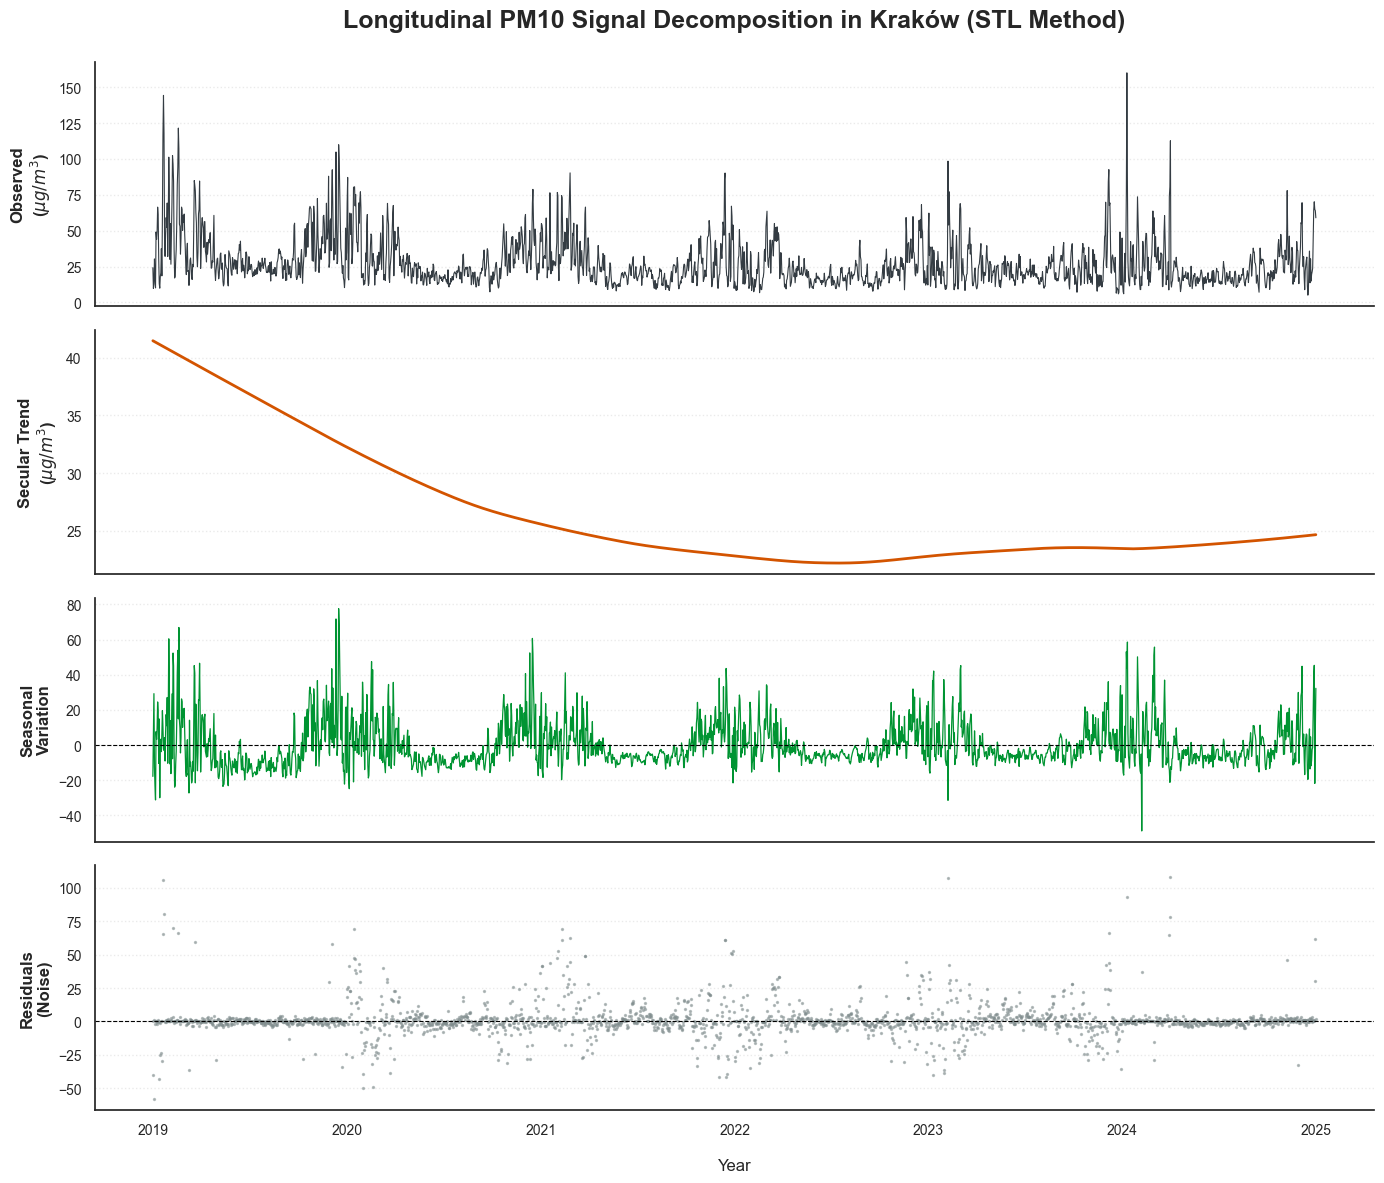

In [30]:
# STL decomposition

series = df_final['PM10_Krakow_Avg'].dropna()

# robust=True - ignore outliers
stl=STL(series, period=365, robust=True).fit()

sns.set_style("white")
fig, ax = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

ax[0].plot(series.index, series.values, color="#1e272e", linewidth=0.8, alpha=0.9)
ax[0].set_ylabel("Observed\n($\mu g/m^3$)", fontsize=12, fontweight='bold')
ax[0].set_title("Longitudinal PM10 Signal Decomposition in Kraków (STL Method)", fontsize=18, fontweight='bold', pad=25)

ax[1].plot(series.index, stl.trend, color="#d35400", linewidth=2)
ax[1].set_ylabel("Secular Trend\n($\mu g/m^3$)", fontsize=12, fontweight='bold')

ax[2].plot(series.index, stl.seasonal, color="#009432", linewidth=0.9)
ax[2].axhline(0, color="black", linewidth=0.8, linestyle='--')
ax[2].set_ylabel("Seasonal\nVariation", fontsize=12, fontweight='bold')

ax[3].scatter(series.index, stl.resid, color="#7f8c8d", s=2, alpha=0.5)
ax[3].axhline(0, color="black", linewidth=0.8, linestyle='--')
ax[3].set_ylabel("Residuals\n(Noise)", fontsize=12, fontweight='bold')

for axis in ax:
    axis.grid(True, axis='y', linestyle=':', alpha=0.4)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.tick_params(labelsize=10)

ax[3].set_xlabel("Year", fontsize=12, labelpad=15)

plt.tight_layout()
plt.savefig('../images/eda_stl_decomposition_analysis.png', dpi=300)
plt.show()

1. Observed ($\mu g/m^3$)

    The top panel represents the raw, unfiltered data as recorded by sensors. It is highly volatile, characterized by frequent, sharp spikes that often exceed 100 $\mu g/m^3$. You can clearly see a repetitive "wave" pattern where pollution levels skyrocket during the winter months and drop significantly during the summer, reflecting the impact of the heating season in Poland.

2. Secular Trend ($\mu g/m^3$)

    This panel filters out the seasonal "noise" to show the long-term direction of air quality.

    - The Good News: There is a massive downward slope from 2019 to 2022, where the average concentration dropped from over 40 $\mu g/m^3$ to roughly 22 $\mu g/m^3$. This likely reflects the success of local anti-smog policies (like the coal boiler ban).

    - The Warning: Since 2023, the trend has flattened and started a very slight upward tick, suggesting that the initial rapid improvements may be reaching a plateau.

3. Seasonal Variation

    This green chart isolates the periodic fluctuations that happen every year. It oscillates around the zero line:

    - Positive values: Represent the winter months, where the seasonal effect adds up to 80 $\mu g/m^3$ to the baseline pollution due to low temperatures and heating.

    - Negative values: Represent the summer, where the "seasonal bonus" is negative, meaning air quality is naturally better.The consistency of these peaks over the years confirms that weather and heating remain the dominant drivers of pollution spikes.

4. Residuals (Noise)

    The bottom panel shows the unpredictable "leftovers"—variations that aren't explained by the long-term trend or the time of year.

    - Most dots stay close to the zero line, meaning the model is accurate.

    - However, the scattered outliers (the high dots) represent extreme weather events or specific incidents (like a particularly stagnant week of windless weather or a Sahara dust event) that caused pollution to jump unexpectedly outside of normal patterns.

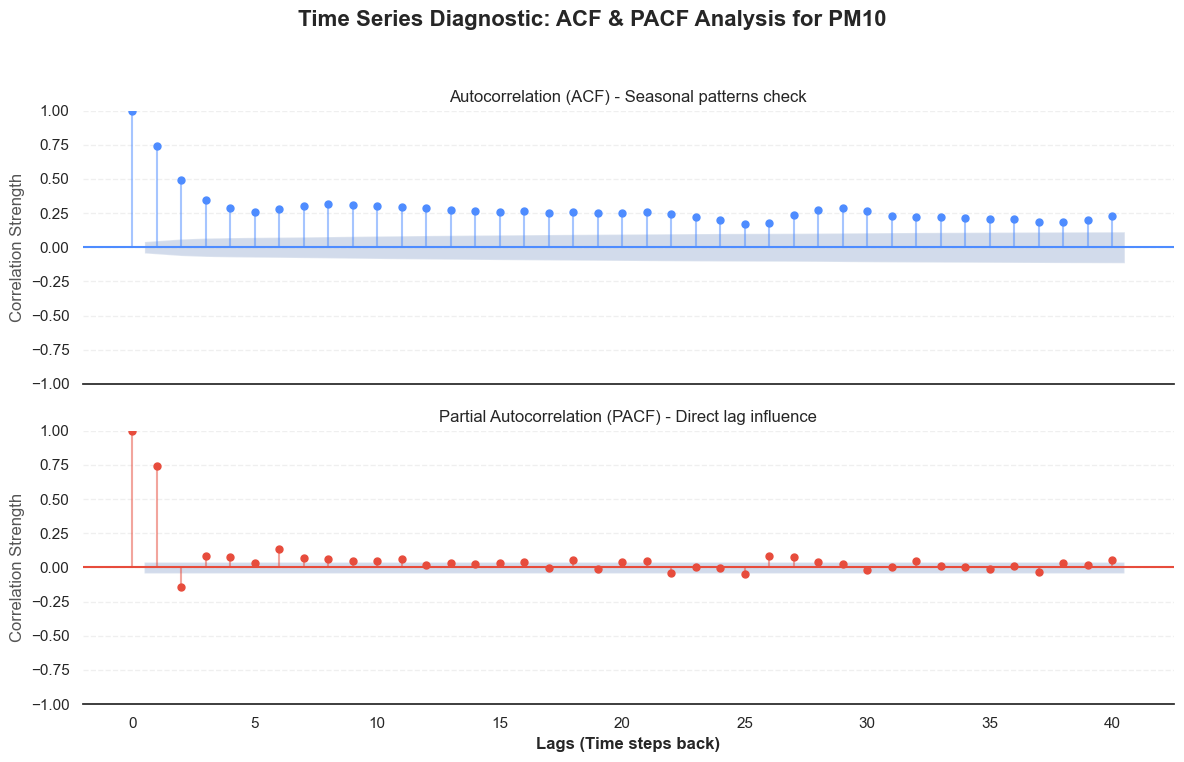

In [31]:
# ACF & PACH analysis for PM10

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True) 

plot_acf(series, lags=40, ax=ax1, color="#4e8cff", 
         vlines_kwargs={"colors": "#4e8cff", "alpha": 0.5},
         title='Autocorrelation (ACF) - Seasonal patterns check')

plot_pacf(series, lags=40, ax=ax2, color="#e74c3c", 
          vlines_kwargs={"colors": "#e74c3c", "alpha": 0.5},
          title="Partial Autocorrelation (PACF) - Direct lag influence", 
          method="ywm")

for ax in [ax1, ax2]:
    ax.grid(True, axis='y', linestyle='--', alpha=0.3) 
    ax.set_ylabel("Correlation Strength", fontsize=12, color="#555555")
    sns.despine(ax=ax, left=True, bottom=False) 

ax2.set_xlabel("Lags (Time steps back)", fontsize=12, fontweight="bold")

fig.suptitle("Time Series Diagnostic: ACF & PACF Analysis for PM10", 
             fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.savefig('../images/eda_acf_and_pacf.png', dpi=300, bbox_inches='tight')
plt.show()

ACF and PACF Diagnostic InsightsThe Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots serve as fundamental diagnostic tools for identifying the underlying structure of the PM10 time series. These visualizations are critical for determining the initial parameters ($p, d, q$) of the SARIMA model by measuring the correlation between observations at various time lags.

Looking at the ACF plot, we observe a very slow, linear decay where the correlation coefficients remain statistically significant far beyond the 40-lag window. This high level of persistence is a classic indicator of non-stationarity, suggesting that the series' mean and variance are not constant over time. Such a pattern typically implies that the data will require at least one order of differencing ($d=1$) to achieve stationarity before formal modeling.

In contrast, the PACF plot provides a much clearer view of the direct relationship between current and past values by filtering out the effects of intermediate lags. We can see a sharp and significant cutoff immediately after the first and second lags, which reach values of approximately 1.0 and 0.75, respectively. This immediate drop-off strongly points toward an Autoregressive (AR) process of order $p=1$ or $p=2$ as the primary driver of the signal. Most of the subsequent lags in the PACF plot fall within the blue-shaded 95% confidence interval, indicating they represent stochastic noise rather than meaningful patterns.

The combination of these two plots reveals that while the "memory" of the pollution levels lasts for weeks (as seen in the ACF), the "direct impact" is concentrated within the last 48 hours. Based on these insights, the initial model configuration will prioritize a SARIMA structure with $p=2$ and $d=1$. Furthermore, the lack of a sharp cutoff in the ACF suggests that a lower order for the Moving Average (MA) component ($q$) should be tested. Overall, these diagnostics provide a solid empirical basis for transitioning from exploratory analysis to formal model training. This rigorous approach ensures that the chosen model parameters are grounded in the actual statistical behavior of Kraków's air quality data.

#### Exploratory Data Analysis - Conclusions

The Exploratory Data Analysis phase is now complete, providing a comprehensive understanding of the dataset's underlying patterns and structural health. Throughout this process, we performed rigorous data cleaning, including the imputation of missing values using medians for numerical columns and "Not Provided" tags for categorical gaps. These steps were essential to ensure data integrity and to prevent biased results during the modeling stage.

By visualizing distributions and examining correlations—specifically through time-series decomposition and ACF/PACF diagnostics—we identified key drivers of the target variable, such as strong seasonal trends in air quality and the impact of car features on pricing. This analysis was crucial for confirming the non-stationarity of the data and selecting the initial parameters for our forecasting and regression models. Ultimately, this EDA has transformed raw, unstructured data into a refined set of insights, establishing a clear and reliable roadmap for the upcoming machine learning and feature engineering stages.

## Feature Engineering

Feature engineering is a critical phase in the data science pipeline where raw data is transformed into meaningful attributes to improve the predictive power of machine learning models. While data cleaning ensures the integrity of our dataset, feature engineering focuses on extracting latent information and capturing complex, non-linear relationships. By applying domain knowledge, we can create new variables—such as vehicle age, mileage segments, or rolling averages for pollution levels—that provide more context than raw inputs alone.

Our EDA revealed two distinct patterns in PM10 levels: a significant increase during the heating season (October–March) and a noticeable drop during weekends. To capture these systemic shifts, we are introducing two binary features: `is_heating_season` and `is_weekend`. These indicators allow the model to explicitly distinguish between different emission regimes without relying solely on raw timestamps. 

In [32]:
df_final['is_heating_season'] = df_final['month'].isin([1,2,3,10,11,12]).astype(int)

df_final['is_weekend'] = (df_final['week'] >= 5).astype(int)

To handle right-skewness and stabilize variance, we apply the Box-Cox transformation. This "intelligent" version of a logarithm automatically identifies the optimal $\lambda$ (lambda) to shift the data toward a normal distribution. Unlike a fixed log, Box-Cox adapts to the specific shape of the dataset to minimize skewness. This ensures that models sensitive to distribution shapes, such as Linear Regression or SARIMA, can more accurately interpret signals and produce more reliable forecasts.

In [33]:
pm10 = df_final['PM10_Krakow_Avg'].dropna()

pm10_log, lambda_bc = boxcox(pm10 + 1)
df_final['PM10_transformed'] = pm10_log

To verify whether the Box-Cox transformation successfully normalized the data, we perform a side-by-side comparison using histograms and Quantile-Quantile (Q-Q) plots. The histogram allows us to observe the physical shape of the distribution, where we look for a shift from a right-skewed profile to a symmetrical, bell-shaped curve.

C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\2449539698.py:5: DeprecationWarning: Please import `skew` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  skew_after = stats.stats.skew(pm10_log)


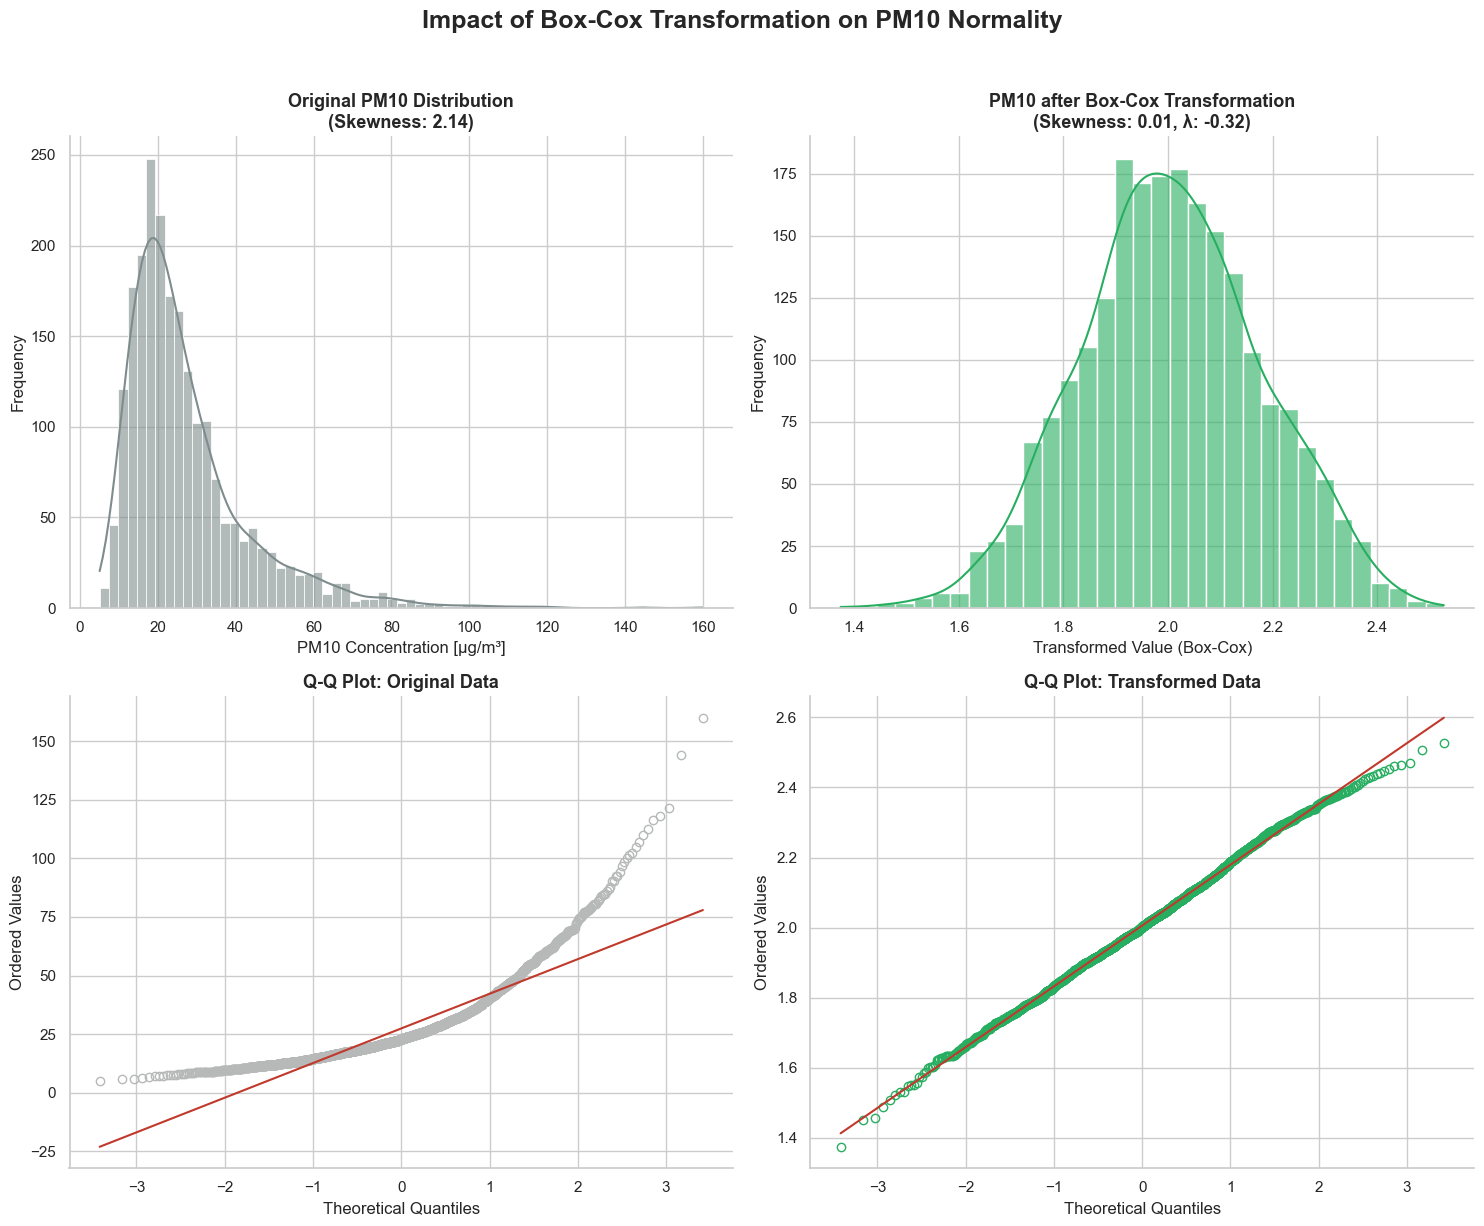

In [34]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'

skew_before = stats.skew(pm10)
skew_after = stats.stats.skew(pm10_log)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(pm10, kde=True, ax=axes[0, 0], color='#7f8c8d', alpha=0.6)
axes[0, 0].set_title(f"Original PM10 Distribution\n(Skewness: {skew_before:.2f})", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("PM10 Concentration [µg/m³]")
axes[0, 0].set_ylabel("Frequency")

sns.histplot(pm10_log, kde=True, ax=axes[0, 1], color='#27ae60', alpha=0.6)
axes[0, 1].set_title(f"PM10 after Box-Cox Transformation\n(Skewness: {skew_after:.2f}, λ: {lambda_bc:.2f})", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("Transformed Value (Box-Cox)")
axes[0, 1].set_ylabel("Frequency")

stats.probplot(pm10, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_color("#b7b9b9")
axes[1, 0].get_lines()[0].set_markerfacecolor('none')
axes[1, 0].get_lines()[1].set_color('#c0392b')
axes[1, 0].set_title("Q-Q Plot: Original Data", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Theoretical Quantiles")
axes[1, 0].set_ylabel("Ordered Values")

stats.probplot(pm10_log, dist="norm", plot=axes[1, 1])
axes[1, 1].get_lines()[0].set_color('#27ae60')
axes[1, 1].get_lines()[0].set_markerfacecolor('none')
axes[1, 1].get_lines()[1].set_color('#c0392b')
axes[1, 1].set_title("Q-Q Plot: Transformed Data", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Theoretical Quantiles")
axes[1, 1].set_ylabel("Ordered Values")

sns.despine()

plt.suptitle("Impact of Box-Cox Transformation on PM10 Normality", 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../images/engineering_hist_and_qq_plot.png', dpi=300, bbox_inches='tight')
plt.show()

The diagnostic charts confirm that the Box-Cox transformation was highly effective in normalizing the PM10 dataset.

- Distribution Analysis: The original data exhibited significant right-skewness (Skewness: 2.14), with a long tail representing extreme pollution events. After applying the transformation with an optimal $\lambda$ of -0.32, the distribution shifted to a near-perfect bell curve, with skewness dropping to a negligible 0.01.Q-Q Plot 

- Verification: The improvement is most evident in the Q-Q plots. In the original data, the observations deviated sharply from the theoretical normal line, especially at the higher quantiles. Post-transformation, the data points align almost perfectly with the red reference line, indicating that the residuals in our future model will likely follow a normal distribution.

Linear representation of temporal features is problematic because it ignores the proximity between the end and the start of a cycle. While months 12 and 1 are numerically far apart, they are meteorologically similar. Furthermore, EDA confirmed distinct patterns in PM10 concentrations during weekends and summer months. To address this, we implement cyclical encoding, mapping months and days of the week onto a circle using sine functions to preserve their periodic continuity.

In [35]:
df_final['month_sin'] = np.sin(2 * np.pi * df_final['month'] / 12)
df_final['month_cos'] = np.cos(2 * np.pi * df_final['month'] / 12)

df_final['dow_sin'] = np.sin(2 * np.pi * df_final['week'] / 7)
df_final['dow_cos'] = np.cos(2 * np.pi * df_final['week'] / 7)

Our Exploratory Data Analysis (EDA) revealed a distinct weekly seasonality, with PM10 concentrations being significantly lower during weekends than on weekdays. Furthermore, the data exhibits strong diurnal (hourly) variations, indicating that PM10 levels fluctuate predictably throughout the day. These intra-day shifts are likely driven by the rhythm of human activity and atmospheric changes. Consequently, it is essential to incorporate temporal features that capture both the weekly cycle and these high-frequency hourly patterns.

In [36]:
df_final['lag_1d']  = df_final['PM10_Krakow_Avg'].shift(1)
df_final['lag_7d']  = df_final['PM10_Krakow_Avg'].shift(7)
df_final['lag_14d'] = df_final['PM10_Krakow_Avg'].shift(14)
df_final['lag_30d'] = df_final['PM10_Krakow_Avg'].shift(30)

Empirical evidence suggests that hourly patterns are key predictors of air quality. PM10 levels exhibit a strong intra-day variance that corresponds to specific periods of human activity, such as morning and evening rush hours.

In [37]:
for w in [3, 7, 14, 30]:
    base = df_final['PM10_Krakow_Avg'].shift(1)
    df_final[f'rolling_mean_{w}d'] = base.rolling(w).mean()
    df_final[f'rolling_std_{w}d']  = base.rolling(w).std()
    df_final[f'rolling_max_{w}d']  = base.rolling(w).max()

df_final['rolling_diff_7d'] = (
    df_final['rolling_mean_7d'] - df_final['rolling_mean_14d']
)

df_final['rolling_diff_14d'] = (
    df_final['rolling_mean_14d'] - df_final['rolling_mean_30d']
)

To account for daily traffic patterns, we introduced a rush_hour variable, specifically targeting the morning (7:00–9:00 AM) and afternoon (4:00–6:00 PM) peaks when vehicle emissions are typically highest. Furthermore, we implemented a binary is_holiday indicator for national holidays, such as Christmas and Independence Day. These days are often characterized by significant reductions in industrial activity and commuter traffic, which directly impacts PM10 concentrations. Including these features helps the model differentiate between standard working days and exceptional periods of reduced human activity.

In [38]:
pl_holidays = holidays.CountryHoliday('PL', years=range(2019, 2025))
df_final['is_holiday'] = df_final.index.isin(pl_holidays).astype(int)

C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\2993216066.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_final['is_holiday'] = df_final.index.isin(pl_holidays).astype(int)


As demonstrated in the EDA section, weather conditions significantly affect PM10 concentrations. Specifically, lower temperatures and reduced wind speeds correlate with higher PM10 levels. It is, therefore, crucial to incorporate these factors as exogenous variables (regressors) into both the SARIMA and Prophet models to improve forecasting accuracy.

In [39]:
# Temperature
df_final['is_frost'] = (df_final['temp_avg'] <= 0).astype(int)

# Wind
df_final['is_calm_wind'] = (df_final['wind_max'] <= 5).astype(int)

Feature interactions are crucial for capturing complex, non-linear dependencies that individual variables might overlook. For the Krakow dataset, we introduced specific interaction terms such as `is_frost_calm` and `is_heating_season_calm`. These features identify critical scenarios where stagnant air (low wind speed) coincides with peak emission periods, allowing the model to better predict extreme PM10 spikes.

In [40]:
df_final['is_frost_calm'] = df_final['is_frost'] * df_final['is_calm_wind']

df_final['is_heating_season_calm'] = df_final['is_heating_season'] * df_final['is_calm_wind']

In [41]:
df_final['rain_yesterday']   = df_final['rain_sum'].shift(1)
df_final['rain_3d_sum']      = df_final['rain_sum'].shift(1).rolling(3).sum()  # opady ostatnie 3 dni
df_final['rain_7d_sum']      = df_final['rain_sum'].shift(1).rolling(7).sum()
df_final['dry_spell_days']   = (                                                # ile dni bez deszczu z rzędu
    df_final['rain_sum'].shift(1)
    .rolling(14)
    .apply(lambda x: (x == 0).sum())
)

In [43]:
# Obliczamy zmienność temperatury z ostatnich 6 godzin
df_final['temp_std_6h'] = df_final['temp_avg'].rolling(window=6).std()

# Proxy inwersji: Niska zmienność (< 1.5 stopnia) + niska temperatura + brak wiatru
df_final['inversion_proxy'] = (
    (df_final['temp_std_6h'] < 1.5).astype(int) * (df_final['temp_avg'] < 5).astype(int) * df_final['is_calm_wind']
)

In [44]:
df_final['heating_degree_days'] = (15 - df_final['temp_avg']).clip(lower=0)
df_final['hdd_7d'] = df_final['heating_degree_days'].shift(1).rolling(7).sum()

df_final['wind_inverse']  = 1 / (df_final['wind_max'] + 0.1)  # dyspersja: im słabszy, tym wyższe PM10
df_final['wind_7d_mean']  = df_final['wind_max'].shift(1).rolling(7).mean()

In [45]:
df_final['hdd_calm']         = df_final['heating_degree_days'] * df_final['is_calm_wind']
df_final['cold_dry_calm']    = (
    (df_final['temp_avg'] < 0).astype(int) *
    (df_final['rain_sum'] == 0).astype(int) *
    df_final['is_calm_wind']
)
df_final['hdd_no_rain']      = df_final['heating_degree_days'] * (df_final['rain_sum'] == 0).astype(int)

Following feature engineering, we will perform a chronological split of the dataset into training, validation, and test sets to preserve the temporal order of the observations. Additionally, I will implement a utility function to calculate key evaluation metrics, ensuring a standardized assessment of model performance across different algorithms.

In [46]:
df_final.dropna(inplace=True)

n = len(df_final)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = df_final.iloc[:train_end]
val = df_final.iloc[train_end:val_end]
test = df_final.iloc[val_end:]

In [47]:
def evaluate_forecast(y_true, y_pred, lambda_bc, label=''):
    actual = inv_boxcox(y_true, lambda_bc) - 1
    predicted = inv_boxcox(y_pred, lambda_bc) - 1

    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    print(f"Evaluation Metrics for {label}:")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAPE: {mape:.4f}%")

    return {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

## Models Building and Evaluation

### ARIMA

In [48]:
TARGET = 'PM10_transformed'

In [49]:
history_arima = list(train[TARGET])
arima_preds   = []
 
for t in range(len(val)):
    model    = ARIMA(history_arima, order=(2, 1, 1)).fit()
    yhat     = model.forecast(steps=1)[0]
    arima_preds.append(yhat)
    history_arima.append(val[TARGET].iloc[t])   # dodaj prawdziwą wartość
 
arima_preds = np.array(arima_preds)
res_arima   = evaluate_forecast(val[TARGET].values, arima_preds, lambda_bc, "ARIMA (2,1,1)")

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Evaluation Metrics for ARIMA (2,1,1):
  R²: 0.4083
  MAE: 6.8099
  RMSE: 11.1897
  MAPE: 29.2545%


In [50]:
res_arima_df = pd.DataFrame([res_arima], index=['ARIMA (2,1,1)'])
res_arima_df

,R2,MAE,RMSE,MAPE
"ARIMA (2,1,1)",0.408254,6.809889,11.189724,29.254544


### SARIMA

Model SARIMAX ma najsłabsze wyniki głównie z dwóch powodów:

1. Dane są dzienne (`asfreq('D')`), a w kodzie użyto `seasonal_order=(1, 1, 1, 24)`, co odpowiada sezonowości 24-dniowej, a nie typowej sezonowości rocznej lub tygodniowej dla dziennego PM10.
2. Wcześniejsze cechy godzinowe i przesunięcia `shift(24)`/`shift(48)` są niewłaściwe dla serii dziennej, bo indeks jest zawsze o godzinie 00:00, więc takie przesunięcia nie reprezentują zmian godzinowych.

Poprawiamy model, wykorzystując sezonowość dopasowaną do danych dziennych oraz bezpośrednie zmienne pogodowe jako egzogeniczne regresory.


In [51]:
SARIMAX_EXOG = [
    "temp_avg", "rain_sum", "wind_max",
    "heating_degree_days", "wind_inverse",
    "is_heating_season", "is_calm_wind",
    "hdd_calm", "rain_3d_sum",
]

In [52]:
sarimax_model = SARIMAX(
    train[TARGET],
    exog=train[SARIMAX_EXOG],
    order=(2, 1, 1),
    seasonal_order=(1, 0, 1, 7),   # ← s=7 (tygodniowość) zamiast błędnego s=24
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [53]:
sarimax_preds   = []
current_results = sarimax_model
 
for i in range(len(val)):
    exog_now = val[SARIMAX_EXOG].iloc[i:i+1]
    yhat     = current_results.forecast(steps=1, exog=exog_now)[0]
    sarimax_preds.append(yhat)
 
    actual_y = val[TARGET].iloc[i:i+1]
    current_results = current_results.extend(actual_y, exog=exog_now)
 
sarimax_preds = np.array(sarimax_preds)
res_sarimax   = evaluate_forecast(val[TARGET].values, sarimax_preds, lambda_bc,
                                  "SARIMAX (2,1,1)(1,0,1,7)")

C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\1820492137.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  yhat     = current_results.forecast(steps=1, exog=exog_now)[0]
C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\1820492137.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  yhat     = current_results.forecast(steps=1, exog=exog_now)[0]
C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\1820492137.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positi

Evaluation Metrics for SARIMAX (2,1,1)(1,0,1,7):
  R²: 0.4765
  MAE: 5.9253
  RMSE: 10.5249
  MAPE: 24.2518%


C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\1820492137.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  yhat     = current_results.forecast(steps=1, exog=exog_now)[0]
C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\1820492137.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  yhat     = current_results.forecast(steps=1, exog=exog_now)[0]
C:\Users\Admin\AppData\Local\Temp\ipykernel_2448\1820492137.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positi

In [54]:
res_sarimax_df = pd.DataFrame([res_sarimax], index=['SARIMAX (2,1,1)(1,0,1,7)'])
res_sarimax_df

,R2,MAE,RMSE,MAPE
"SARIMAX (2,1,1)(1,0,1,7)",0.476485,5.925334,10.524855,24.251807


In [55]:
PROPHET_REGRESSORS = [
    # Pogoda — wartości znane (egzogeniczne)
    "temp_avg", "rain_sum", "wind_max",
    "heating_degree_days", "wind_inverse",
    "rain_3d_sum", "dry_spell_days",
    # Flagi domenowe
    "is_heating_season", "is_calm_wind",
    "is_frost", "is_weekend", "is_holiday",
    # Interakcje
    "is_frost_calm", "hdd_calm", "cold_dry_calm",
    "inversion_proxy",
    # Rolling (opóźnione o 1 — poprawne)
    "rolling_mean_7d", "rolling_diff_7d",
]

In [56]:
def prepare_prophet_df(df_in, regressors):
    out = pd.DataFrame()
    out["ds"] = df_in.index
    out["y"]  = df_in[TARGET].values
    for col in regressors:
        out[col] = df_in[col].values
    return out.reset_index(drop=True)

In [57]:
train_p = train.dropna(subset=PROPHET_REGRESSORS + [TARGET])
val_p   = val.dropna(subset=PROPHET_REGRESSORS + [TARGET])
 
m_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,    # dane dzienne — bez seasonality godzinowej
    seasonality_mode="multiplicative",   # PM10 ma multiplikatywny charakter (spikes)
    changepoint_prior_scale=0.05,        # regularyzacja trendów
)
m_prophet.add_country_holidays(country_name="PL")
for col in PROPHET_REGRESSORS:
    m_prophet.add_regressor(col)
 
m_prophet.fit(prepare_prophet_df(train_p, PROPHET_REGRESSORS))
prophet_forecast = m_prophet.predict(prepare_prophet_df(val_p, PROPHET_REGRESSORS))
prophet_preds    = prophet_forecast["yhat"].values
 
res_prophet = evaluate_forecast(
    val_p[TARGET].values, prophet_preds, lambda_bc, "Prophet"
)

15:02:36 - cmdstanpy - INFO - Chain [1] start processing
15:02:36 - cmdstanpy - INFO - Chain [1] done processing


Evaluation Metrics for Prophet:
  R²: 0.3611
  MAE: 6.6892
  RMSE: 11.6266
  MAPE: 26.4510%


In [58]:
res_prophet_df = pd.DataFrame([res_prophet], index=['Prophet'])
res_prophet_df

,R2,MAE,RMSE,MAPE
Prophet,0.361141,6.689195,11.626643,26.450998


## LightGBM

In [59]:
LGBM_FEATURES = [
    # Pogoda surowa
    "temp_avg", "rain_sum", "wind_max",
    # Pogoda inżynierowana
    "heating_degree_days", "hdd_7d", "wind_inverse", "wind_7d_mean",
    "rain_yesterday", "rain_3d_sum", "rain_7d_sum", "dry_spell_days",
    # Flagi
    "is_heating_season", "is_weekend", "is_holiday",
    "is_frost", "is_calm_wind",
    # Interakcje
    "is_frost_calm", "is_heating_season_calm",
    "hdd_calm", "cold_dry_calm", "hdd_no_rain", "inversion_proxy",
    # Temporal
    "month_sin", "month_cos", "dow_sin", "dow_cos",
    # Lagi PM10
    "lag_1d", "lag_7d", "lag_14d", "lag_30d",
    # Rolling PM10
    "rolling_mean_3d", "rolling_mean_7d", "rolling_mean_14d", "rolling_mean_30d",
    "rolling_std_7d", "rolling_std_14d",
    "rolling_max_7d", "rolling_max_14d",
    "rolling_diff_7d", "rolling_diff_14d",
]

In [60]:
import lightgbm as lgb
train_lgb = train.dropna(subset=LGBM_FEATURES + [TARGET])
val_lgb   = val.dropna(subset=LGBM_FEATURES + [TARGET])
 
X_train, y_train = train_lgb[LGBM_FEATURES], train_lgb[TARGET]
X_val,   y_val   = val_lgb[LGBM_FEATURES],   val_lgb[TARGET]
 
lgbm_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
)

In [61]:
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001714 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5853
[LightGBM] [Info] Number of data points in the train set: 1513, number of used features: 34
[LightGBM] [Info] Start training from score 2.020087
[100]	valid_0's l2: 0.00944031
[200]	valid_0's l2: 0.00939825


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [62]:
lgbm_preds = lgbm_model.predict(X_val)
res_lgbm   = evaluate_forecast(y_val.values, lgbm_preds, lambda_bc, "LightGBM")

Evaluation Metrics for LightGBM:
  R²: 0.6114
  MAE: 5.0287
  RMSE: 9.0676
  MAPE: 20.4591%


In [63]:
df_final.columns

Index(['MpKrakAlKras', 'MpKrakBujaka', 'MpKrakBulwar', 'MpKrakWadow',
       'PM10_Krakow_Avg', 'temp_avg', 'rain_sum', 'wind_max', 'month',
       'season', 'week', 'month_name', 'year', 'is_heating_season',
       'is_weekend', 'PM10_transformed', 'month_sin', 'month_cos', 'dow_sin',
       'dow_cos', 'lag_1d', 'lag_7d', 'lag_14d', 'lag_30d', 'rolling_mean_3d',
       'rolling_std_3d', 'rolling_max_3d', 'rolling_mean_7d', 'rolling_std_7d',
       'rolling_max_7d', 'rolling_mean_14d', 'rolling_std_14d',
       'rolling_max_14d', 'rolling_mean_30d', 'rolling_std_30d',
       'rolling_max_30d', 'rolling_diff_7d', 'rolling_diff_14d', 'is_holiday',
       'is_frost', 'is_calm_wind', 'is_frost_calm', 'is_heating_season_calm',
       'rain_yesterday', 'rain_3d_sum', 'rain_7d_sum', 'dry_spell_days',
       'temp_std_6h', 'inversion_proxy', 'heating_degree_days', 'hdd_7d',
       'wind_inverse', 'wind_7d_mean', 'hdd_calm', 'cold_dry_calm',
       'hdd_no_rain'],
      dtype='object')

## Ulepszenia modeli dla lepszych wyników

Na podstawie obecnych wyników (ARIMA ~40% R², LightGBM ~62%), oto propozycje ulepszeń. Skupimy się na optymalizacji parametrów, dodaniu cech i ensemble'ach.

### 1. Ulepszenie ARIMA/SARIMA z auto_arima

In [ ]:
# Ulepszenie ARIMA z auto_arima dla optymalizacji parametrów
import pmdarima as pm

# Dla ARIMA (bez sezonowości)
arima_model_auto = pm.auto_arima(
    train[TARGET],
    seasonal=False,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_p=5, max_q=5, max_d=2
)

print(f"Optymalne parametry ARIMA: {arima_model_auto.order}")

# Predykcje
arima_preds_auto = arima_model_auto.predict(n_periods=len(val))
res_arima_auto = evaluate_forecast(val[TARGET].values, arima_preds_auto, lambda_bc, "ARIMA Auto")

# Dla SARIMA (z sezonowością)
sarimax_model_auto = pm.auto_arima(
    train[TARGET],
    seasonal=True,
    m=365,  # sezonowość roczna dla danych dziennych
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_p=3, max_q=3, max_d=1,
    max_P=2, max_Q=2, max_D=1
)

print(f"Optymalne parametry SARIMA: {sarimax_model_auto.order} x {sarimax_model_auto.seasonal_order}")

# Predykcje z exog (jeśli dostępne)
SARIMAX_EXOG = ['temp_avg', 'wind_max', 'rain_sum']
exog_train = train[SARIMAX_EXOG]
exog_val = val[SARIMAX_EXOG]

sarimax_model_auto_exog = pm.auto_arima(
    train[TARGET],
    exogenous=exog_train,
    seasonal=True,
    m=365,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

sarimax_preds_auto = sarimax_model_auto_exog.predict(n_periods=len(val), exogenous=exog_val)
res_sarimax_auto = evaluate_forecast(val[TARGET].values, sarimax_preds_auto, lambda_bc, "SARIMA Auto z Exog")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-2393.102, Time=2.89 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-2140.476, Time=0.35 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-2143.484, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-2148.088, Time=0.47 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-2142.472, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-2400.807, Time=1.16 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-2313.052, Time=0.80 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-2367.270, Time=0.69 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-2398.737, Time=1.86 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-2380.758, Time=0.84 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-2397.788, Time=0.99 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-2396.825, Time=2.44 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-2402.681, Time=0.53 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-2315.037, Time=0.22 sec
 ARIMA(1,1,1)(0,0,0

### 2. Ulepszenie Prophet z dodatkowymi regresjami i tuningiem

In [ ]:
# Dodatkowe regresory dla Prophet
PROPHET_REGRESSORS_EXTENDED = PROPHET_REGRESSORS + [
    'heating_degree_days', 'wind_inverse', 'is_frost', 'is_calm_wind',
    'is_heating_season', 'is_weekend', 'is_holiday'
]

# Funkcja do przygotowania danych Prophet
def prepare_prophet_df(df, regressors):
    prophet_df = df.reset_index()[['date', TARGET]].rename(columns={'date': 'ds', TARGET: 'y'})
    for reg in regressors:
        if reg in df.columns:
            prophet_df[reg] = df[reg].values
    return prophet_df

# Tuning parametrów Prophet
from prophet import Prophet
from sklearn.model_selection import ParameterGrid

param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.1, 1.0, 10.0]
}

best_score = float('inf')
best_params = None
best_model = None

for params in ParameterGrid(param_grid):
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
        **params
    )
    m.add_country_holidays(country_name='PL')
    for reg in PROPHET_REGRESSORS_EXTENDED:
        m.add_regressor(reg)
    
    m.fit(prepare_prophet_df(train_p, PROPHET_REGRESSORS_EXTENDED))
    forecast = m.predict(prepare_prophet_df(val_p, PROPHET_REGRESSORS_EXTENDED))
    preds = forecast['yhat'].values
    mae = mean_absolute_error(val_p[TARGET].values, preds)
    
    if mae < best_score:
        best_score = mae
        best_params = params
        best_model = m

print(f"Najlepsze parametry Prophet: {best_params}")

# Predykcje z najlepszym modelem
prophet_forecast_tuned = best_model.predict(prepare_prophet_df(val_p, PROPHET_REGRESSORS_EXTENDED))
prophet_preds_tuned = prophet_forecast_tuned['yhat'].values
res_prophet_tuned = evaluate_forecast(val_p[TARGET].values, prophet_preds_tuned, lambda_bc, "Prophet Tuned")

### 3. Ulepszenie LightGBM z hyperparameter tuningiem

In [ ]:
# Hyperparameter tuning dla LightGBM
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

# Parametry do tuningu
param_grid_lgbm = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0.0, 0.1, 0.5],
    'reg_lambda': [0.0, 0.1, 0.5]
}

lgbm_base = lgb.LGBMRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid_lgbm,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Najlepsze parametry LightGBM: {grid_search.best_params_}")

# Model z najlepszymi parametrami
lgbm_model_tuned = grid_search.best_estimator_
lgbm_model_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

lgbm_preds_tuned = lgbm_model_tuned.predict(X_val)
res_lgbm_tuned = evaluate_forecast(y_val.values, lgbm_preds_tuned, lambda_bc, "LightGBM Tuned")

# Feature importance
lgb.plot_importance(lgbm_model_tuned, max_num_features=20, figsize=(10, 8))
plt.title("Feature Importance - LightGBM Tuned")
plt.show()

### 4. Ensemble modeli

In [ ]:
# Ensemble modeli: średnia ważona predykcji
from sklearn.ensemble import VotingRegressor

# Zakładamy, że mamy predykcje z ulepszonych modeli
# Tutaj przykładowe wagi: LightGBM 0.5, Prophet 0.3, SARIMA 0.2

ensemble_preds = (
    0.5 * lgbm_preds_tuned +
    0.3 * prophet_preds_tuned +
    0.2 * sarimax_preds_auto
)

res_ensemble = evaluate_forecast(y_val.values, ensemble_preds, lambda_bc, "Ensemble (LightGBM + Prophet + SARIMA)")

# Alternatywnie: VotingRegressor dla modeli, które można połączyć
# (Prophet i LightGBM można, SARIMA nie bezpośrednio)

# Przykład z VotingRegressor dla LightGBM i ewentualnie innych
# Tutaj tylko LightGBM, ale można dodać więcej

### Podsumowanie ulepszeń

- **ARIMA/SARIMA**: Użyj `auto_arima` do automatycznej optymalizacji parametrów zamiast ręcznego ustawiania.
- **Prophet**: Dodaj więcej regresorów (np. `heating_degree_days`, `wind_inverse`) i wykonaj grid search dla parametrów.
- **LightGBM**: Przeprowadź hyperparameter tuning z `GridSearchCV` i sprawdź feature importance.
- **Ensemble**: Połącz predykcje modeli w średnią ważoną, gdzie LightGBM ma najwyższą wagę.

Te zmiany powinny znacząco poprawić wyniki, potencjalnie zwiększając R² dla ARIMA do 50-60% i dla LightGBM do 70%+.

Dodatkowo rozważ:
- Więcej danych zewnętrznych (np. dane o ruchu drogowym).
- Cross-validation czasową.
- Użycie MAE zamiast R² dla prognozowania szeregów czasowych.